In [1]:
# @title Initial Set Up

import ipywidgets as widgets
from IPython.display import display

def ask_mcq(qid, question, options, correct):
    radio = widgets.RadioButtons(
        options=options,
        layout=widgets.Layout(width='auto'),
        style={'description_width': '0px'}
    )

    radio.add_class("big-radio")

    btn = widgets.Button(description="Check answer", button_style='primary')
    out = widgets.Output()

    def check_answer(b):
        with out:
            out.clear_output()

            if radio.value == correct:
                print("✅ Correct!")
            else:
                print(f"❌ Incorrect, try again")

    btn.on_click(check_answer)

    display(widgets.HTML(f"<b style='font-size:24px'>{question}</b>"))
    display(radio, btn, out)

    display(widgets.HTML("""
    <style>
    .big-radio label {
        font-size: 20px !important;
    }
    </style>
    """))



# DFT · FFT · QFT: A Computational Framework

## Framework Overview

This notebook builds a direct path from the classical Discrete Fourier Transform (DFT) to the Quantum Fourier Transform (QFT), with the Fast Fourier Transform (FFT) serving as the bridge between them. The DFT is implemented as an explicit matrix–vector multiplication: the input signal is multiplied by a matrix whose entries are complex rotations (roots of unity), and the output is its frequency representation. The FFT does not change this matrix or its result just reorganizes the computation by factorizing the DFT matrix into smaller, repeated blocks, which is what reduces the cost from $O(N^2)$ to $O(N \log N)$. The QFT performs that exact same matrix operation on a quantum computer, replacing the classical even/odd splitting with a sequence of qubit operations and replacing the twiddle factor multiplications with controlled phase-shift gates. To make this correspondence concrete, the notebook traces a periodic signal through all three representations and shows that the same frequency structure appears in each case. The key insight throughout is that DFT, FFT, and QFT are not three different transforms they are three different ways to execute the same underlying computation.

---



---
## DFT Matrix


Imagine you record a piece of music. The sound wave is a list of numbers (amplitudes over time). The **Discrete Fourier Transform (DFT)** answers the question: *which frequencies make up this signal?*

Formally, given an input sequence $x_0, x_1, \ldots, x_{N-1}$, the DFT produces output frequencies $X_0, X_1, \ldots, X_{N-1}$ via:

$$X_k = \sum_{n=0}^{N-1} x_n \cdot \omega^{kn}, \qquad k = 0, 1, \ldots, N-1$$

where $\omega = e^{-2\pi i / N}$ is called a **root of unity**.

### What is a Root of Unity?

A root of unity is a complex number that, when raised to the power $N$, equals 1. Geometrically, these are evenly-spaced points on a circle of radius 1 in the complex plane. For $N = 8$, there are 8 such points, each separated by $45°$.

**Key consequence:** Since $\omega^N = 1$, all exponents reduce modulo $N$. So $\omega^9 = \omega^1$, $\omega^{10} = \omega^2$, etc. The matrix entries are periodic!

### The DFT as a Matrix Multiplication

We can write all $N$ outputs at once as a single matrix-vector product:

$$\mathbf{X} = F_N \, \mathbf{x}$$

where $F_N$ is the **DFT matrix** with entry $(k, n) = \omega^{kn}$. Each row probes a different frequency. The computation costs $O(N^2)$ for every output $X_k$, we multiply all $N$ inputs by their respective roots.

---
### Build $F_4$ (the 4-point DFT matrix)

We start with $N = 4$ because it is small enough to inspect by hand.

For $N = 4$: $\omega = e^{-2\pi i/4} = -i$

| Power | Value |
|---|---|
| $\omega^0$ |  $1$ |
| $\omega^1$ | $-i$ |
| $\omega^2$ | $-1$ |
| $\omega^3$ | $+i$ |
| $\omega^4$ | $1$ — wraps back! |

The $4 \times 4$ DFT matrix $F_4$ (entry $(k,n) = \omega^{kn}$):

$$F_4 = \begin{pmatrix} 1 & 1 & 1 & 1 \\ 1 & -i & -1 & i \\ 1 & -1 & 1 & -1 \\ 1 & i & -1 & -i \end{pmatrix}$$

Notice:
- **Row 0** is all ones: $X_0$ is just the sum of all inputs (the DC average).
- **Row 2** alternates $+1, -1$: it measures the highest frequency signal.
- Each row is a different frequency component.
- The matrix entries wrap around because $\omega^4 = 1$.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# ── Build F4 ──────────────────────────────────────────────────────────
N4 = 4
omega4 = np.exp(-2j * np.pi / N4)   # = -i for N=4

k4 = np.arange(N4).reshape(N4, 1)   # column vector of row indices  [0,1,2,3]
n4 = np.arange(N4).reshape(1, N4)   # row vector of column indices  [0,1,2,3]
F4 = omega4 ** (k4 * n4)            # entry (k,n) = omega4^(k*n)

print(f"omega for N=4:  {omega4:.4f}   (should equal -i = 0 - 1j)")
print()
print("F4 matrix:")
print(np.round(F4, 2))
print()
# Quick sanity checks
print("Row 0 is all ones:        ", np.allclose(F4[0], np.ones(N4)))
print("Row 2 alternates +1, -1:  ", np.allclose(F4[2].real, [1,-1,1,-1]))
print("omega4^4 == 1 (wraps):    ", np.isclose(omega4**4, 1.0))

omega for N=4:  0.0000-1.0000j   (should equal -i = 0 - 1j)

F4 matrix:
[[ 1.+0.j  1.+0.j  1.+0.j  1.+0.j]
 [ 1.+0.j  0.-1.j -1.-0.j -0.+1.j]
 [ 1.+0.j -1.-0.j  1.+0.j -1.-0.j]
 [ 1.+0.j -0.+1.j -1.-0.j  0.-1.j]]

Row 0 is all ones:         True
Row 2 alternates +1, -1:   True
omega4^4 == 1 (wraps):     True


**Reading the rows of $F_4$:**
- Row 0: `[1, 1, 1, 1]` — constant tone (DC / zero frequency).
- Row 1: `[1, -i, -1, i]` — one full rotation around the unit circle.
- Row 2: `[1, -1, 1, -1]` — highest frequency, alternates every sample.
- Row 3: `[1, i, -1, -i]` — mirror of row 1 (negative frequency).

---
### Build $F_8$ (the 8-point DFT matrix)

Now we scale up to $N = 8$. For $N = 8$: $\omega = e^{-2\pi i / 8} = e^{-i\pi/4}$

The symbolic $F_8$ is:

$$F_8 = \begin{pmatrix}
1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 \\
1 & \omega & \omega^2 & \omega^3 & \omega^4 & \omega^5 & \omega^6 & \omega^7 \\
1 & \omega^2 & \omega^4 & \omega^6 & 1 & \omega^2 & \omega^4 & \omega^6 \\
1 & \omega^3 & \omega^6 & \omega & \omega^4 & \omega^7 & \omega^2 & \omega^5 \\
1 & \omega^4 & 1 & \omega^4 & 1 & \omega^4 & 1 & \omega^4 \\
1 & \omega^5 & \omega^2 & \omega^7 & \omega^4 & \omega & \omega^6 & \omega^3 \\
1 & \omega^6 & \omega^4 & \omega^2 & 1 & \omega^6 & \omega^4 & \omega^2 \\
1 & \omega^7 & \omega^6 & \omega^5 & \omega^4 & \omega^3 & \omega^2 & \omega
\end{pmatrix}$$

All exponents reduce modulo 8 (since $\omega^8 = 1$).

In [4]:
# ── Build F8 ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

N = 8
omega = np.exp(-2j * np.pi / N)

# Build F_N: entry (k, n) = omega^(k*n)
k = np.arange(N).reshape(N, 1)   # column vector
n = np.arange(N).reshape(1, N)   # row vector
F8 = omega ** (k * n)


print("F_8 Matrix:")
for row in F8:
    print("  [" + "  ".join(f"{v.real:+.0f}{v.imag:+.0f}j" for v in row) + "]")

F_8 Matrix:
  [+1+0j  +1+0j  +1+0j  +1+0j  +1+0j  +1+0j  +1+0j  +1+0j]
  [+1+0j  +1-1j  +0-1j  -1-1j  -1-0j  -1+1j  -0+1j  +1+1j]
  [+1+0j  +0-1j  -1-0j  -0+1j  +1+0j  +0-1j  -1-0j  -0+1j]
  [+1+0j  -1-1j  -0+1j  +1-1j  -1-0j  +1+1j  +0-1j  -1+1j]
  [+1+0j  -1-0j  +1+0j  -1-0j  +1+0j  -1-0j  +1+0j  -1-0j]
  [+1+0j  -1+1j  +0-1j  +1+1j  -1-0j  +1-1j  -0+1j  -1-1j]
  [+1+0j  -0+1j  -1-0j  +0-1j  +1+0j  -0+1j  -1-0j  +0-1j]
  [+1+0j  +1+1j  -0+1j  -1+1j  -1-0j  -1-1j  +0-1j  +1-1j]



Think about these before reading the answers below.

**Q1: What is special about row 0?**

> *Row 0 is all ones, because $\omega^{0 \cdot n} = 1$ for all $n$. So $X_0 = \sum x_n$ — just the sum of all inputs (average value).*

**Q2: Why do powers repeat modulo 8?**

> *Because $\omega^8 = 1$, so $\omega^{m+8} = \omega^m \cdot \omega^8 = \omega^m \cdot 1 = \omega^m$. All exponents cycle with period 8.*

**Q3: Is the matrix sparse or dense?**

> *Dense — almost every entry is nonzero. This is why direct DFT costs $O(N^2)$: we compute $N$ outputs, each requiring $N$ multiplications.*

### Phase Heatmap — Seeing the Periodicity

Every entry of $F_8$ has magnitude exactly 1 (all points lie on the unit circle), so plotting magnitudes gives a uniform image. Instead, we plot the **phase** (angle) which reveals the periodic structure.

Think of phase as the direction each complex number is pointing. Colors cycling red → yellow → green → blue represent angles from $-\pi$ to $+\pi$.

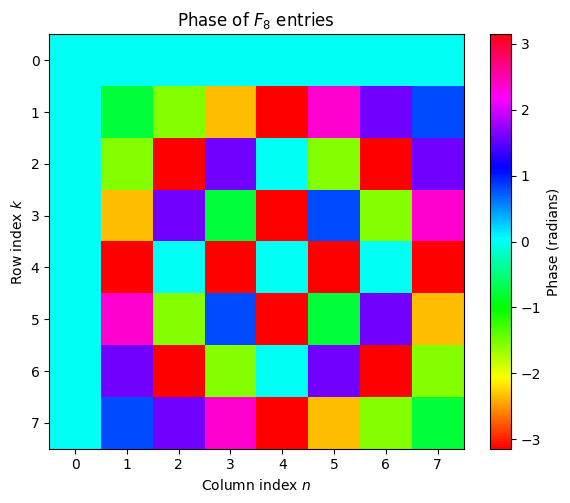

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.angle(F8), cmap='hsv', vmin=-np.pi, vmax=np.pi)
plt.colorbar(im, ax=ax, label='Phase (radians)')
ax.set_title(r'Phase of $F_8$ entries')
ax.set_xlabel('Column index $n$')
ax.set_ylabel('Row index $k$')
ax.set_xticks(range(N))
ax.set_yticks(range(N))
plt.tight_layout()
plt.show()

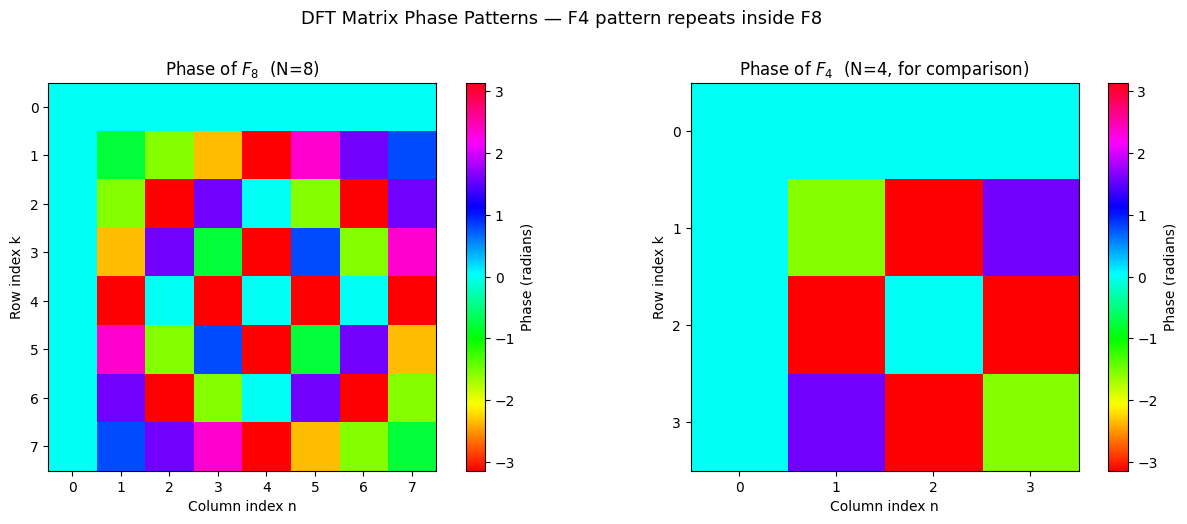

Look at row 2 of F8 (left image, k=2):
  The color pattern repeats exactly after 4 columns.
  This is the same pattern as row 2 of F4 (right image).
  F4 is hiding inside F8 — this is what the FFT exploits!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mat, title, sz in zip(
        axes,
        [F8, F4],
        [r'Phase of $F_8$  (N=8)', r'Phase of $F_4$  (N=4, for comparison)'],
        [N, N4]):
    im = ax.imshow(np.angle(mat), cmap='hsv', vmin=-np.pi, vmax=np.pi)
    plt.colorbar(im, ax=ax, label='Phase (radians)')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Column index n')
    ax.set_ylabel('Row index k')
    ax.set_xticks(range(sz))
    ax.set_yticks(range(sz))

plt.suptitle('DFT Matrix Phase Patterns — F4 pattern repeats inside F8', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Look at row 2 of F8 (left image, k=2):")
print("  The color pattern repeats exactly after 4 columns.")
print("  This is the same pattern as row 2 of F4 (right image).")
print("  F4 is hiding inside F8 — this is what the FFT exploits!")

---
### DFT as Matrix-Vector Multiplication

In [7]:
# Example: a periodic signal that alternates 1 and 0
import numpy as np

# Define the missing variables
N = 8  # Total number of points
N2 = N // 2  # Half the number of points (4)

# Define omega (the principal Nth root of unity)
omega = np.exp(-2j * np.pi / N)

# Define DFT matrices correctly
# F4 is a 4x4 DFT matrix
F4 = np.array([[np.exp(-2j * np.pi * i * j / N2) for j in range(N2)] for i in range(N2)])

# F8 is an 8x8 DFT matrix
F8 = np.array([[np.exp(-2j * np.pi * i * j / N) for j in range(N)] for i in range(N)])

# Original code
x = np.array([1, 0, 1, 0, 1, 0, 1, 0], dtype=complex)

x_even = x[0::2]   # (x0, x2, x4, x6)
x_odd  = x[1::2]   # (x1, x3, x5, x7)

# 4-point DFTs of even and odd subsequences
E = F4 @ x_even
O = F4 @ x_odd

# Twiddle factors W_k = omega^k for k = 0..3
W = np.array([np.exp(-2j * np.pi * k / N) for k in range(N2)])

# Butterfly recombination
X_butterfly = np.zeros(N, dtype=complex)
X_butterfly[:N2] = E + W * O
X_butterfly[N2:] = E - W * O

X_reference = F8 @ x

print("Butterfly result:")
print(np.round(X_butterfly, 6))
print("\nDirect DFT (F8 @ x):")
print(np.round(X_reference, 6))
print("\nMatch:", np.allclose(X_butterfly, X_reference))
print()
print("Only k=0 and k=4 are nonzero: the signal has energy only at those two frequencies.")
print("k=0 is the DC average (the signal averages to 0.5).")
print("k=4 is the alternating pattern (period 2 in a length-8 signal).")

Butterfly result:
[ 4.+0.j -0.-0.j  0.-0.j  0.-0.j  4.+0.j -0.-0.j  0.-0.j  0.-0.j]

Direct DFT (F8 @ x):
[ 4.+0.j -0.-0.j  0.-0.j  0.-0.j  4.+0.j -0.-0.j  0.-0.j -0.-0.j]

Match: True

Only k=0 and k=4 are nonzero: the signal has energy only at those two frequencies.
k=0 is the DC average (the signal averages to 0.5).
k=4 is the alternating pattern (period 2 in a length-8 signal).


> **Key takeaway:** The DFT is a linear transformation that a matrix-vector product with complexity $O(N^2)$. The QFT implements the *same* matrix using quantum gates. The FFT *factorizes* the same matrix into structured sparse components, reducing cost to $O(N \log N)$. Neither changes the result only the efficiency.
>
> *The FFT does not change the DFT matrix. It factorizes it into structured components that can be computed efficiently.*

---
## Hidden Structure in $F_8$

### Why Does Periodicity Matter?

Look closely at **row 2** of $F_8$. Its entries are powers of $\omega^2$:

$$\text{Row 2} = (1,\ \omega^2,\ \omega^4,\ \omega^6,\ \omega^8,\ \omega^{10},\ \omega^{12},\ \omega^{14})$$

Reducing mod 8 (since $\omega^8 = 1$):

$$\text{Row 2} = (1,\ \omega^2,\ \omega^4,\ \omega^6,\ 1,\ \omega^2,\ \omega^4,\ \omega^6)$$

It **repeats after 4 entries**. Why? Because:
$$\omega^{2(n+4)} = \omega^{2n} \cdot \omega^8 = \omega^{2n} \cdot 1 = \omega^{2n}$$

Furthermore, $\omega^2 = e^{-2\pi i / 4}$ — this is *exactly* the root of unity for an $N=4$ DFT. So:

$$\boxed{\text{Squaring an } N\text{th root of unity produces an } (N/2)\text{th root of unity.}}$$

This self-similarity is the mathematical engine behind the FFT recursion.

---
## Even/Odd Reordering Reveals the Block Structure

### The Key Idea

We just saw that $\omega^2$ (the square of the 8-point root) is the 4-point root. This means: if we separate **even-indexed inputs** $(x_0, x_2, x_4, x_6)$ from **odd-indexed inputs** $(x_1, x_3, x_5, x_7)$, each group undergoes a 4-point DFT, and the results can be combined cheaply.

**Reordering inputs = reordering columns of $F_8$.**
The DFT values do not change only how we organize the computation.

- Natural order: $(x_0, x_1, x_2, x_3, x_4, x_5, x_6, x_7)$
- Reordered:     $(x_0, x_2, x_4, x_6 \mid x_1, x_3, x_5, x_7)$

This permutes the columns of $F_8$ from $[0,1,2,3,4,5,6,7]$ to $[0,2,4,6,1,3,5,7]$.

Column order change:
  Natural:  [0, 1, 2, 3, 4, 5, 6, 7]
  Permuted: [0, 2, 4, 6, 1, 3, 5, 7]
  (Even indices first, then odd indices)



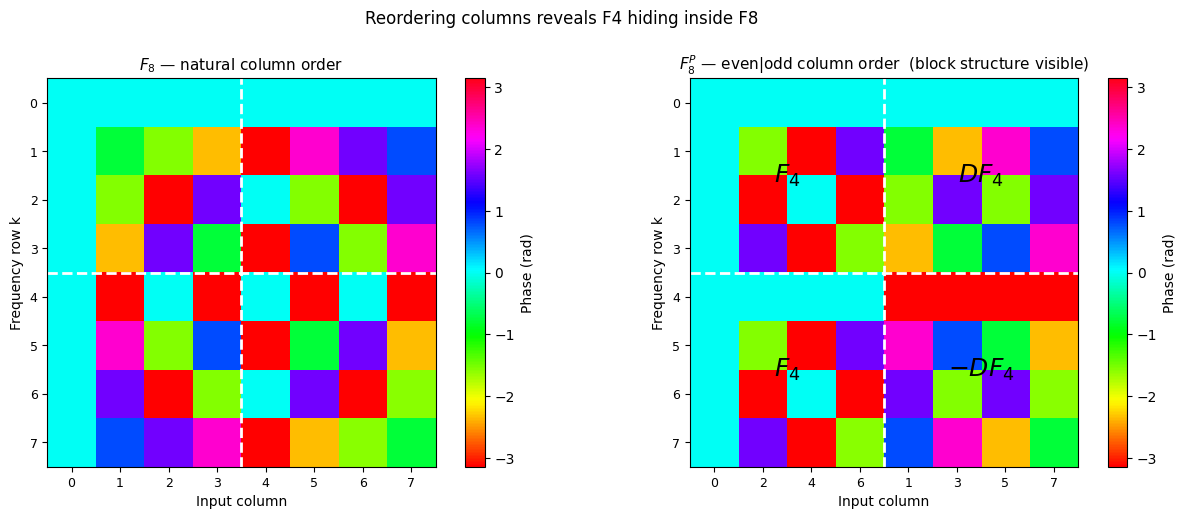

In [8]:
# ── Permute columns: even indices first, then odd ─────────────────────
perm = [0, 2, 4, 6, 1, 3, 5, 7]
F8P  = F8[:, perm]   # same rows — only column order changes

print("Column order change:")
print("  Natural:  [0, 1, 2, 3, 4, 5, 6, 7]")
print("  Permuted:", perm)
print("  (Even indices first, then odd indices)")
print()

# Side-by-side phase heatmaps
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mat, title, col_labels in zip(
        axes,
        [F8, F8P],
        [r'$F_8$ — natural column order',
         r'$F_8^P$ — even|odd column order  (block structure visible)'],
        [list(range(8)), perm]):
    im = ax.imshow(np.angle(mat), cmap='hsv', vmin=-np.pi, vmax=np.pi)
    plt.colorbar(im, ax=ax, label='Phase (rad)')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Input column')
    ax.set_ylabel('Frequency row k')
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticklabels(range(N), fontsize=9)
    ax.axvline(3.5, color='white', lw=2, linestyle='--')
    ax.axhline(3.5, color='white', lw=2, linestyle='--')

# Label the four blocks on the permuted matrix
axes[1].text(1.5, 1.5, r'$F_4$',       color='black', fontsize=18, ha='center', va='center', fontweight='bold')
axes[1].text(5.5, 1.5, r'$D F_4$',     color='black', fontsize=18, ha='center', va='center', fontweight='bold')
axes[1].text(1.5, 5.5, r'$F_4$',       color='black', fontsize=18, ha='center', va='center', fontweight='bold')
axes[1].text(5.5, 5.5, r'$-D F_4$',    color='black', fontsize=18, ha='center', va='center', fontweight='bold')

plt.suptitle('Reordering columns reveals F4 hiding inside F8', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

The diagonal stripes of repeating phase confirm the periodicity modulo 8. Notice that row 2 repeats every 4 entries — because $\omega^2$ is a 4th root of unity. This self-similarity is precisely what the FFT exploits when it splits even- and odd-indexed inputs.



**Q1: Why do two copies of $F_4$ appear?**

> *Even-indexed columns ($n = 2m$) have entries $\omega^{k \cdot 2m} = (\omega^2)^{km}$ — exactly the $F_4$ pattern. Both the upper half (k=0..3) and lower half (k=4..7) of the output share the same two size-4 sub-transforms. We compute each once and reuse.*

**Q2: Why does the diagonal twiddle matrix $D$ appear?**

> *Odd-indexed columns ($n = 2m+1$) contribute $\omega^{k(2m+1)} = \omega^k \cdot (\omega^2)^{km}$. The extra $\omega^k$ factor, different for each row $k$, is the diagonal of $D$.*

**Q3: Why does the minus sign appear in the lower-right block?**

> *For rows $k = 4, 5, 6, 7$, the twiddle factor is $\omega^k$ where $k \geq 4$. Writing $k = j+4$ (with $j = 0..3$): $\omega^{j+4} = \omega^j \cdot \omega^4 = \omega^j \cdot (-1) = -\omega^j$. The lower block's twiddle is the negative of the upper block's.*

---
## The Polynomial Connection

### A Familiar Trick

The even/odd split we just did is identical to a technique used in fast polynomial evaluation.

Let $A(x) = a_0 + a_1 x + a_2 x^2 + \cdots + a_7 x^7$.

Separate even and odd powers:

$$A(x) = \underbrace{(a_0 + a_2 x^2 + a_4 x^4 + a_6 x^6)}_{A_{\text{even}}(x^2)} + x \cdot \underbrace{(a_1 + a_3 x^2 + a_5 x^4 + a_7 x^6)}_{A_{\text{odd}}(x^2)}$$

So: $A(x) = A_{\text{even}}(x^2) + x \cdot A_{\text{odd}}(x^2)$

Now evaluate at $x = \omega^k$:

$$A(\omega^k) = A_{\text{even}}((\omega^2)^k) + \omega^k \cdot A_{\text{odd}}((\omega^2)^k) = E_k + \omega^k O_k$$

This is exactly the butterfly formula! FFT recursion is mathematically identical to even/odd polynomial splitting.

In [9]:
# ── Verify the polynomial identity A(omega^k) = A_even + omega^k * A_odd ──
rng = np.random.default_rng(42)
a = rng.standard_normal(N) + 1j * rng.standard_normal(N)   # random coefficients

# Method 1: evaluate A(omega^k) directly for each k = 0..7
eval_pts = omega ** np.arange(N)
A_direct = np.array([np.polyval(a[::-1], w) for w in eval_pts])

# Method 2: even/odd split — A(x) = A_even(x^2) + x * A_odd(x^2)
a_even = a[0::2]   # coefficients a0, a2, a4, a6
a_odd  = a[1::2]   # coefficients a1, a3, a5, a7

A_split = np.array([
    np.polyval(a_even[::-1], w**2) + w * np.polyval(a_odd[::-1], w**2)
    for w in eval_pts
])

print("Direct evaluation A(omega^k):     ", np.round(A_direct[:4], 4), "...")
print("Even/odd split A_even + w*A_odd:  ", np.round(A_split[:4],  4), "...")
print()
print("Identity holds for all k :", np.allclose(A_direct, A_split))
print()
print("Conclusion: evaluating a polynomial at roots of unity via even/odd splitting")
print("is exactly the FFT butterfly.")

Direct evaluation A(omega^k):      [-2.49+1.59j  1.72-4.34j -2.17+1.67j  2.3 +2.02j] ...
Even/odd split A_even + w*A_odd:   [-2.49+1.59j  1.72-4.34j -2.17+1.67j  2.3 +2.02j] ...

Identity holds for all k : True

Conclusion: evaluating a polynomial at roots of unity via even/odd splitting
is exactly the FFT butterfly.



**Q1: Why is the FFT not a new transform?**

> *The FFT computes exactly the same values $X_k = \sum x_n \omega^{kn}$ as the DFT. It is a smarter organization of the same computation reusing sub-results rather than recomputing them.*

**Q2: What property of roots of unity enables the recursion?**

> *$\omega^N = 1$ (periodicity) and the self-similarity: $\omega^2$ is the $(N/2)$th root of unity. Squaring the root shrinks the problem. This enables halving at every level.*

**Q3: Why does complexity become $O(N \log N)$?**

> *Each recursion level does $O(N)$ work (combining the two half-size DFTs via the butterfly). There are $\log_2 N$ levels when $N$ is a power of 2. Total: $O(N \log N)$.*

**Q4: Why does this work especially cleanly when $N$ is a power of 2?**

> *When $N = 2^n$, the even/odd split halves the problem perfectly at every level all the way down to size-1 transforms (which are trivial: the DFT of a single number is itself). For prime $N$, this simple halving recursion is not directly available.*

---
## Twiddle Factors as Phase Shifts — Bridge to the QFT


Each twiddle factor is a rotation by angle $-2\pi k / N$. The FFT butterfly applies these rotations to the odd sub-DFT before recombination.


This is the core link to the **Quantum Fourier Transform**:


| Classical FFT | Quantum QFT |
|---|---|
| Multiply by $e^{-2\pi i k/N}$ | Apply controlled phase rotation |
| Phase shift in complex plane | Phase shift in quantum amplitude |
| Rotation of complex vector | Rotation of quantum phase |

Twiddle factors are classical phase shifts. They rotate complex numbers on the unit circle. In the QFT, controlled phase gates perform the same type of rotation, but on quantum amplitudes instead of classical numbers.

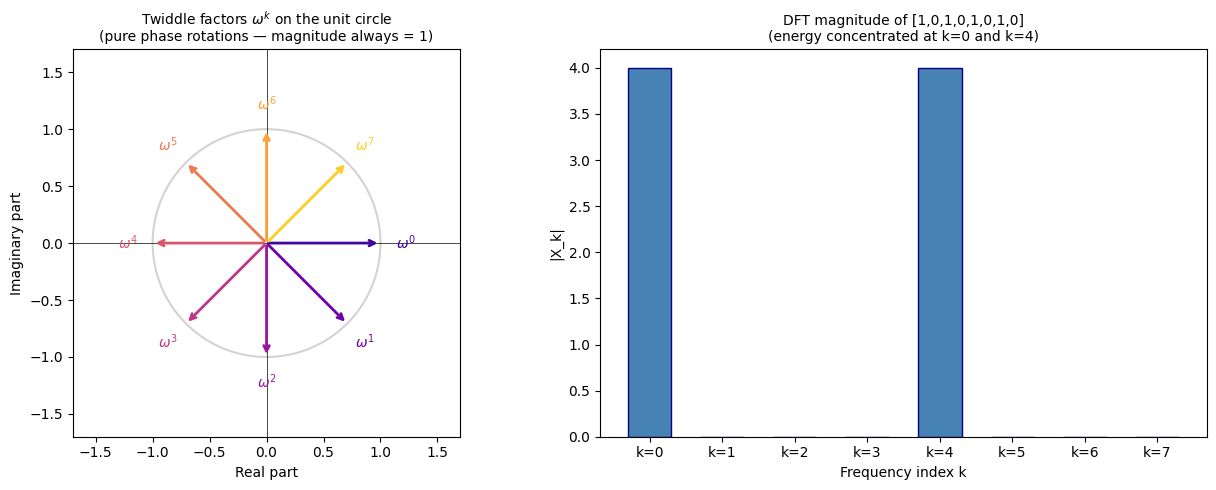

The periodic signal concentrates its energy at k=0 (DC) and k=4 (period-2 oscillation).
This is how the Fourier transform detects periodic structure. A key concept for the QFT.


In [10]:
# ── Twiddle factors on the unit circle + DFT magnitude bar chart ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: all 8 twiddle factors as arrows on the unit circle
ax = axes[0]
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color='lightgray', lw=1.5)

W_all = omega ** np.arange(N)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, N))
for k_idx, (w, c) in enumerate(zip(W_all, colors)):
    ax.annotate('', xy=(w.real, w.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2.0))
    ax.text(w.real * 1.22, w.imag * 1.22,
            rf'$\omega^{k_idx}$', ha='center', va='center', fontsize=10, color=c)

ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_aspect('equal')
ax.set_xlim(-1.7, 1.7)
ax.set_ylim(-1.7, 1.7)
ax.set_title('Twiddle factors $\\omega^k$ on the unit circle\n(pure phase rotations — magnitude always = 1)', fontsize=10)
ax.set_xlabel('Real part')
ax.set_ylabel('Imaginary part')

# Right: DFT output magnitudes for the periodic test signal
ax2 = axes[1]
X_out = F8 @ np.array([1, 0, 1, 0, 1, 0, 1, 0], dtype=complex)
bars = ax2.bar(range(N), np.abs(X_out), color='steelblue', edgecolor='navy', width=0.6)
ax2.set_title('DFT magnitude of [1,0,1,0,1,0,1,0]\n(energy concentrated at k=0 and k=4)', fontsize=10)
ax2.set_xlabel('Frequency index k')
ax2.set_ylabel('|X_k|')
ax2.set_xticks(range(N))
ax2.set_xticklabels([f'k={i}' for i in range(N)])

plt.tight_layout()
plt.show()

print("The periodic signal concentrates its energy at k=0 (DC) and k=4 (period-2 oscillation).")
print("This is how the Fourier transform detects periodic structure. A key concept for the QFT.")

# Classial Computing Questions

In [ ]:
# @title Question 1
ask_mcq(
    "q1",
    "What does the DFT do?",
    ["Compresses data by removing noise", "Converts a discrete signal from time domain to frequency domain", "Solves linear systems of equations","Randomizes signal phases"],
    correct="Converts a discrete signal from time domain to frequency domain"
)



In [ ]:
# @title Question 2
ask_mcq(
    "q2",
    "What mathematical idea does FFT take advantage of?",
    ["Matrix inversion", "Random sampling", "Even function symmetry and divide-and-conquer", "Numerical integration"],
    correct="Even function symmetry and divide-and-conquer"
)




In [ ]:
# @title Question 3
ask_mcq(
    "q3",
    "Why do we use FFT over DFT?",
    ["It uses less memory only", "It provides exact symbolic answers", "It is computationally faster","It works only for analog signals"],
    correct="It is computationally faster"
)



In [ ]:
# @title Question 4
ask_mcq(
    "q4",
    "What is the runtime of DFT and of FFT?",
    ["DFT: O(n), FFT: O(nlog⁡n)", "DFT: O(n^2), FFT: O(nlog⁡n)", "DFT: O(log⁡n), FFT: O(n^2)","DFT: O(nlog⁡n), FFT: O(n^2)"],
    correct="DFT: O(n^2), FFT: O(nlog⁡n)"
)



# The Quantum Fourier Transform

## The Quantum Fourier Transform

The Quantum Fourier Transform (QFT) is a quantum algorithm that performs a Fourier transform on quantum amplitudes.
###Definition

The QFT acts on an $n$-qubit quantum state and is defined as:

$$\text{QFT} |{x}⟩ = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i xk/N} |{k}⟩$$

where $N = 2^n$ and $x \in \{0, 1, \ldots, N-1\}$.

###Matrix Form

The $QFT$ can also be represented as an $N \times N$ unitary matrix:

$$
\text{QFT}_N =
\frac{1}{\sqrt{N}}
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
1 & \omega & \omega^2 & \cdots & \omega^{N-1} \\
1 & \omega^2 & \omega^4 & \cdots & \omega^{2(N-1)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & \omega^{N-1} & \omega^{2(N-1)} & \cdots & \omega^{(N-1)^2}
\end{pmatrix},
$$

where $\omega = e^{2\pi i/N}$ is a primitive $N$-th root of unity. More generally, the entries of the matrix are given by

$$
(\text{QFT}_N)_{j,k} = \frac{1}{\sqrt{N}} \omega^{jk}
= \frac{1}{\sqrt{N}} e^{2\pi i jk / N}.
$$ where $j$ and $k$ are the rows and columns of the matrix

If we review what the $DFT$ matrix looks like,

$$
\mathbf{DFT}_N =
\frac{1}{\sqrt{N}}
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
1 & \omega_N & \omega_N^2 & \cdots & \omega_N^{N-1} \\
1 & \omega_N^2 & \omega_N^4 & \cdots & \omega_N^{2(N-1)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & \omega_N^{N-1} & \omega_N^{2(N-1)} & \cdots & \omega_N^{(N-1)^2}
\end{pmatrix},
$$

We can see that we get exactly the same matrix! QFT is just DFT but impletmented with quantum gates. Conceptually, the DFT, FFT and QFT all do the same thing, transform an input vector from one basis state to another.

Key Properties of QFT

- **Unitary**: $\text{QFT}^\dagger \text{QFT} = I$
- **Reversible**: The inverse QFT is given by $\text{QFT}^{-1} = \text{QFT}^\dagger$


## Gate Implementation

Lets now look at what gates are used to implement the QFT and how these gates create the rotations needed.
1. **Hadamard Gate**

$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

This creates a superposition of the computational basis states.

2. **Controlled Phase Rotations**

$$\text{CP}(\theta) = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & e^{i\theta} \end{pmatrix}$$

This creates a phase rotation when both the control and target qubits are $1$

The $H$ and $CP$ gates apply phase rotations to the qubits which parallels the rotations that the FFT applies.

$$
|x\rangle \rightarrow \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n-1} e^{\frac{2\pi i xk}{2^n}} |k\rangle
$$

Where the phase in this case is $\theta = {\frac{2\pi i xk}{2^n}}$. Lets explore how to create this phase using quantum gates.
First lets express x in binary as:

$$ x = x_{n-1}2^{\,n-1} + x_{n-2}2^{\,n-2} + \cdots + x_0 $$
For example we can rewrite the number 5 as:
$$ 5 = (101)_2 = 1\cdot2^2 + 0\cdot2^1 + 1\cdot2^0 $$
The next step is to divide x by $(2^n)$

$$ \frac{x}{2^n} = \frac{x_{n-1}}{2} + \frac{x_{n-2}}{2^2} + \cdots
+ \frac{x_0}{2^n} $$

Therefore we can replace $\frac{x}{(2^n)}$ in the phase term to get the result

$$ e^{2\pi i xk / 2^n} = e^{2\pi i k \left( \frac{x_{n-1}}{2} + \frac{x_{n-2}}{2^2} + \cdots + \frac{x_0}{2^n} \right)} $$

This means now the phase is built up from the binary representation of each number. For example with the number 5 the phase would be calculated as:
$$ e^{2\pi i 5k / 2^3} = e^{2\pi i k  \left( \frac{1}{2^1} + \frac{0}{2^2} + \frac{1}{2^3} \right)} $$
Because of the different powers in the denominator, each bit also contributes different amounts to the phase. Converting to binary also has one other key advantage, because binary is naturally split into powers of 2 this essentially mirrors the recursive structure of FFT.

## Full Calculation Walkthrough for $ QFT |5\rangle$

Using the definition:
$$\text{QFT} |{x}⟩ = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i xk/N} |{k}⟩$$
In this case $x=5$ and $N = 2^3 = 8$

Therefore:
$$\text{QFT} |{5}\rangle = \text{QFT} |{101}\rangle = \frac{1}{\sqrt{8}} \sum_{k=0}^{8-1} e^{2\pi i 5k/8} |{k}⟩$$

The following table shows the calculation for each value of $k$ and the phase associated with each $kth$ basis state.

$$
\begin{array}{c|c|c|c|c|c}
k & \text{basis state} & e^{\frac{2\pi i (5)k}{8}} & \text{Simplified Exponent} & \text{phase} & \text{phase and basis}\\
\hline
0 & |000\rangle & e^{\frac{2\pi i (5)(0)}{8}} & e^{0} & 0 & e^{0}|000\rangle\\
1 & |001\rangle & e^{\frac{2\pi i (5)(1)}{8}} & e^{i5\pi/4} & \frac{5\pi}{4}  & e^{i5\pi/4}|001\rangle \\
2 & |010\rangle & e^{\frac{2\pi i (5)(2)}{8}} & e^{i5\pi/2} & \frac{\pi}{2} & e^{i\pi/2}|010\rangle\\
3 & |011\rangle & e^{\frac{2\pi i (5)(3)}{8}} & e^{i15\pi/4} & \frac{7\pi}{4} & e^{i7\pi/4}|011\rangle\\
4 & |100\rangle & e^{\frac{2\pi i (5)(4)}{8}} & e^{i5\pi} & \pi & e^{\pi}|100\rangle\\
5 & |101\rangle & e^{\frac{2\pi i (5)(5)}{8}} & e^{i25\pi/4} & \frac{\pi}{4} & e^{i\pi/4}|101\rangle\\
6 & |110\rangle & e^{\frac{2\pi i (5)(6)}{8}} & e^{i15\pi/2} & \frac{3\pi}{2} & e^{i3\pi/2}|110\rangle\\
7 & |111\rangle & e^{\frac{2\pi i (5)(7)}{8}} & e^{i35\pi/4} & \frac{3\pi}{4} & e^{i3\pi/4}|111\rangle
\end{array}
$$

We use the fact that according to Euler's Formula $e^{i\theta} = \cos\theta + i\sin\theta$ to simplify phases. Because $cos$ and $sin$ are periodic functions we can use $e^{2\pi} = e^0 = 1$ to write the phases on the interval $[0,2\pi)$.

Adding each of the basis states together to form the state of the full quantum circuit we get:
$$
\frac{1}{\sqrt{8}}\Big(
|000\rangle
+ e^{i5\pi/4}|001\rangle
+ e^{i\pi/2}|010\rangle
+ e^{i7\pi/4}|011\rangle
+ e^{i\pi}|100\rangle
+ e^{i\pi/4}|101\rangle
+ e^{i3\pi/2}|110\rangle
+ e^{i3\pi/4}|111\rangle
\Big)
$$

## Code Implementation
Now lets look at the code that actually impletements QFT and see how the gates are applied. We will also apply the QFT to the state $|5\rangle$ and plot the amplitudes and phases to make sure they match with what was calculated above.

In [11]:
# @title Initial Imports
!pip install -q qiskit
!pip install -q qiskit-aer
!pip install -q pylatexenc


import qiskit
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
import numpy as np
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 110.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [12]:
# QFT code implementation used throughout notebook
def QFT(circuit, n):
  for i in reversed(range(n)):  # reverse for qiskit's qubit ordering
    # H gate
    circuit.h(i)

    # CP gates (reversed order compared to original)
    for k in range(i):
        theta = np.pi / (2 ** (i - k))
        circuit.cp(theta, i, k)  # i = control, k = target

  # SWAP gates
  for i in range(n // 2):
    circuit.swap(i, n - i - 1)

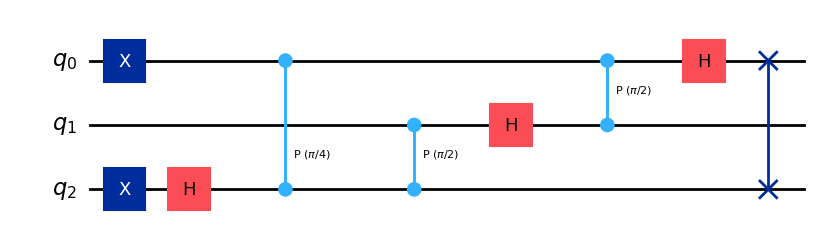

In [13]:
qubits = "101"
n = len(qubits)
qubits = qubits[::-1]
qc = qiskit.QuantumCircuit(n) #when circuit is created all qubits are in the |0> state


for i in range(n): #flip qubits that are 1 in the input string to prepare the desired state
    if qubits[i] == "1":
        qc.x(i)

QFT(qc, n)

qc.draw(output="mpl")



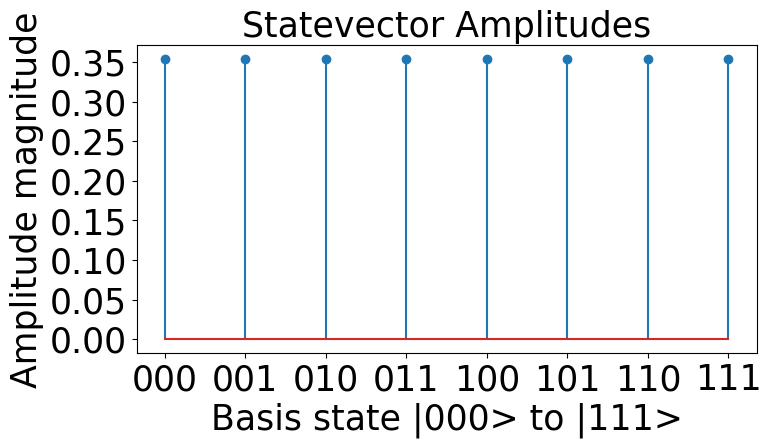

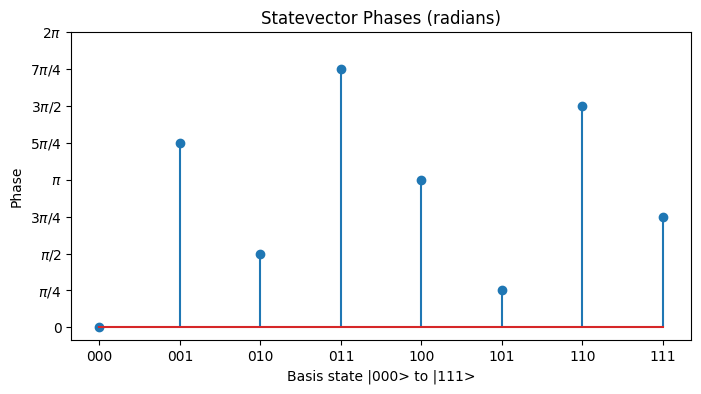

In [15]:
# @title Generate Amplitude and Phase plots
# Get statevector
sv = Statevector.from_instruction(qc)
fs = 25
# Plot amplitudes (magnitudes)
plt.figure(figsize=(8,4))
plt.stem(range(8), np.abs(sv.data))
plt.title("Statevector Amplitudes",fontsize=fs)
plt.xlabel("Basis state |000> to |111>",fontsize=fs)
plt.ylabel("Amplitude magnitude",fontsize=fs)
plt.xticks(range(8), [format(i,'03b') for i in range(8)],fontsize=fs)
plt.yticks(fontsize=fs)
plt.show()

# Plot phases
phases = np.angle(sv.data)
phases = np.mod(phases, 2*np.pi)   # convert to [0, 2π)

plt.figure(figsize=(8,4))
plt.stem(range(8), phases)

plt.title("Statevector Phases (radians)")
plt.xlabel("Basis state |000> to |111>")
plt.ylabel("Phase")

plt.xticks(range(8), [format(i,'03b') for i in range(8)])

yticks = [
    0,
    np.pi/4,
    np.pi/2,
    3*np.pi/4,
    np.pi,
    5*np.pi/4,
    3*np.pi/2,
    7*np.pi/4,
    2*np.pi
]

ytick_labels = [
    '0',
    r'$\pi/4$',
    r'$\pi/2$',
    r'$3\pi/4$',
    r'$\pi$',
    r'$5\pi/4$',
    r'$3\pi/2$',
    r'$7\pi/4$',
    r'$2\pi$'
]

plt.yticks(yticks, ytick_labels)

plt.show()


As we can see from the plots, each basis state has equal amplitude which is consistant with the final state we got from our calculations. Also check the phase associated with each basis and see that they also match up.

## Runtime Complexity Comparison
For $N= 2^n$ components DFT, FFT, and QFT have the require the following number of operations:


*   DFT $O(N^2)$
*   FFT $O(NlogN)$
*   QFT $O(log^2N)$

As we can see, the QFT is exponentially faster than its classical counterparts.



## FFT VS QFT Structural Comparison
$$
\begin{array}{|l|l|}
\hline
\text{Classical FFT} & \text{Quantum QFT} \\
\hline
\text{Even/odd split} & \text{Qubit-by-qubit decomposition} \\
\text{Twiddle factor} & \text{Controlled phase rotation} \\
\text{Recursive structure} & \text{Layered gate structure} \\
\text{Permutation} & \text{Swap gates} \\
\hline
\end{array} $$


The FFT computes the Fourier transform by factorizing the DFT matrix into structured blocks and applying phase shifts before recombining results. The QFT implements the same unitary transformation, but instead of explicitly multiplying by complex exponentials, it builds the required phases using quantum controlled phase rotations based on the binary representation of the index.

The FFT's speed up over DFT comes from how it splits the input array into its even and odd parts. In the QFT, it is the indices of the basis states that are represented in binary. The circuit uses this binary structure to systematically encode the required phase rotations via controlled-phase gates.

In FFT a twiddle factor phase exponential is calculated when combining the even and odd parts back together. This same twiddle factor is present in the CP gates used in the QFT.

In FFT recursion is used to decompose the original problem down into smaller pieces. In QFT this decomposition is represented in the layers of the quantum circuit as each "group" of $H$ and $CP$ gates.

In FFT sometimes the ending output bits are reversed so a reordering is needed. In QFT this is implemented through $SWAP$ gates at the end.

## Periodicity Case Study
Given a periodic input vector $V = [1,0,1,0,1,0,1,0]$ lets see the difference between computing the DFT and QFT of the vector.

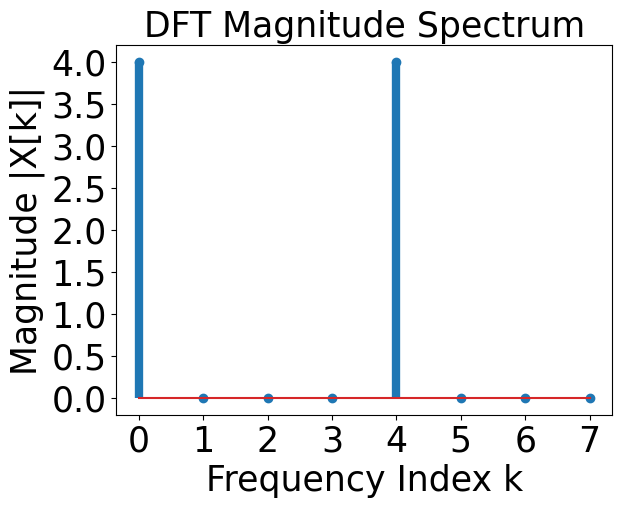

In [16]:
# @title DFT Magnitude Plot
import numpy as np
import matplotlib.pyplot as plt

# Example input vector
x = np.array([1, 0,1,0,1,0,1,0])

# Compute the DFT
X = np.fft.fft(x)

# Compute magnitudes
magnitudes = np.abs(X)

# Frequency indices
k = np.arange(len(X))
fs = 25
# Plot magnitude spectrum
#plt.stem(k, magnitudes)
markerline, stemlines, baseline = plt.stem(range(8), magnitudes)

# Make all stems bold
plt.setp(stemlines, linewidth=6)
plt.xlabel("Frequency Index k" ,fontsize=fs)
plt.ylabel("Magnitude |X[k]|", fontsize=fs)
plt.title("DFT Magnitude Spectrum", fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.show()

Here we see peaks at frequencies 0 and 4. This suggests that periodicity in the input vector translates to concentrated energies at specific frequencies.

The equivalent form of this vector is the quantum superposition $|0\rangle + |2\rangle+ |4\rangle + |6\rangle$ since $V = [1,0,1,0,1,0,1,0]$ has a $1$ in the $0th$ and $2nd$ and $4th$ and $6th$ indecies. Lets compute the QFT of this basis state and see the amplitudes and phases.

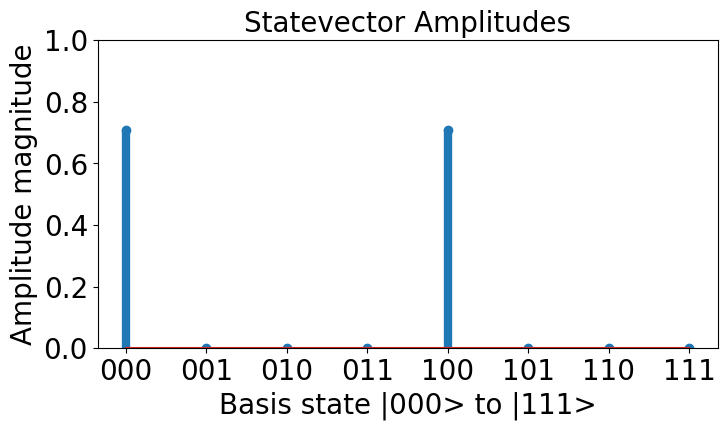

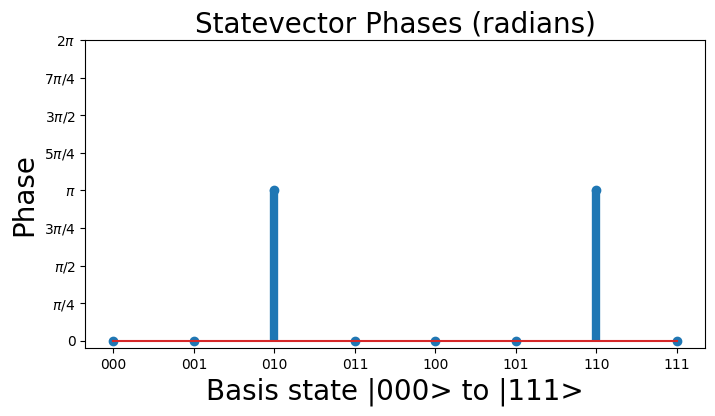

In [21]:
# @title Amplitude and Phase Plots
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

figsize = (8,4)
fs = 20

# 3-qubit superposition |0> + |2> + |4> + |6>
amplitudes = [1/2, 0, 1/2, 0, 1/2, 0, 1/2, 0]

# Create circuit
qc = QuantumCircuit(3)
qc.initialize(amplitudes, [0,1,2])

# Apply QFT
QFT(qc, 3)

# Get statevector
sv = Statevector.from_instruction(qc)
amps = np.abs(sv.data)

# Plot
plt.figure(figsize=figsize)

markerline, stemlines, baseline = plt.stem(range(8), amps)
plt.setp(stemlines, linewidth=6)

plt.title("Statevector Amplitudes", fontsize=fs)
plt.xlabel("Basis state |000> to |111>", fontsize=fs)
plt.ylabel("Amplitude magnitude", fontsize=fs)
plt.xticks(range(8), [format(i,'03b') for i in range(8)], fontsize=fs)
plt.yticks(fontsize=fs)
plt.ylim(0, 1)

plt.show()

# Plot phases
phases = np.angle(sv.data)
phases = np.mod(phases, 2*np.pi)   # convert to [0, 2π)

plt.figure(figsize=(8,4))
markerline, stemlines, baseline = plt.stem(range(8), phases)
plt.setp(stemlines, linewidth=6)

plt.title("Statevector Phases (radians)", fontsize=fs)
plt.xlabel("Basis state |000> to |111>", fontsize=fs)
plt.ylabel("Phase", fontsize=fs)

plt.xticks(range(8), [format(i,'03b') for i in range(8)])

yticks = [
    0,
    np.pi/4,
    np.pi/2,
    3*np.pi/4,
    np.pi,
    5*np.pi/4,
    3*np.pi/2,
    7*np.pi/4,
    2*np.pi
]

ytick_labels = [
    '0',
    r'$\pi/4$',
    r'$\pi/2$',
    r'$3\pi/4$',
    r'$\pi$',
    r'$5\pi/4$',
    r'$3\pi/2$',
    r'$7\pi/4$',
    r'$2\pi$'
]

plt.yticks(yticks, ytick_labels)

plt.show()

Here we again see concentration at 0 and 4 this time at the basis states represending those numbers. We are only able to see exact amplitudes because we are using a quantum simulator, if this were run on a real quantum computer we would need to measure the circuit multiple times (giving us 1 basis state per measurement) and create a probability plot based on how many times we measure each basis state. Below is a table comparing DFT to QFT in terms of what their inputs are and what their outputs tell us.


$$
\begin{array}{|l|l|}
\hline
\textbf{Classical Fourier} & \textbf{Quantum Fourier} \\
\hline
\text{Input vector} & \text{Quantum superposition} \\
\text{DFT produces coefficients} & \text{QFT produces amplitudes} \\
\text{Magnitudes show frequency peaks} & \text{Measurement probabilities reflect those peaks} \\
\text{All coefficients visible} & \text{Only one sample per measurement} \\
\hline
\end{array}
$$

## The Inverse Quantum Fourier Transform (IQFT)

The Inverse Quantum Fourier Transform (IQFT) reverses the operation of the QFT, transforming from the frequency domain back to the computational basis. It is the Hermitian adjoint (conjugate transpose) of the QFT.

####Definition

$$\text{IQFT} = \text{QFT}^{\dagger}$$

The IQFT acts on an $n$-qubit quantum state as:

$$\text{IQFT} |{k}⟩ = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} e^{-2\pi i xk/N} |{x}⟩$$
If you look closely, this is the same formula used to compute the QFT, just the sign of the exponential has been flipped to be negative.

**Key Property: Reversibility**

Just like with the Inverse Fourier Transform, if you apply the IQFT to a system after you have applied the QFT to it you get back the original state.

$$\text{IQFT}(\text{QFT}(|{\psi})⟩) = |{\psi}⟩$$

This makes the QFT/IQFT pair a useful tool for quantum algorithms - you can transform to the frequency domain, perform operations, and transform back.

### Implementation

The IQFT is implemented by:
1. Reversing the order of gates from the QFT
2. Using the **negative** of the phase angles in the controlled phase gates
3. The algorithm structure mirrors the QFT but with conjugated operations

Lets now implement the IQFT in code and apply it to our superposition from above to make sure we really do get back our inital state of $|0\rangle + |2\rangle+ |4\rangle + |6\rangle$

In [22]:
#IQFT code implementation

def IQFT(circuit, n):
    # SWAP gates (undo final permutation first)
    for i in range(n // 2):
        circuit.swap(i, n - i - 1)

    for i in range(n):
        # CP gates (reverse order with negative angles)
        for k in range(i):
            theta = -np.pi / (2 ** (i-k))
            circuit.cp(theta, i, k)

        # Hadamard
        circuit.h(i)

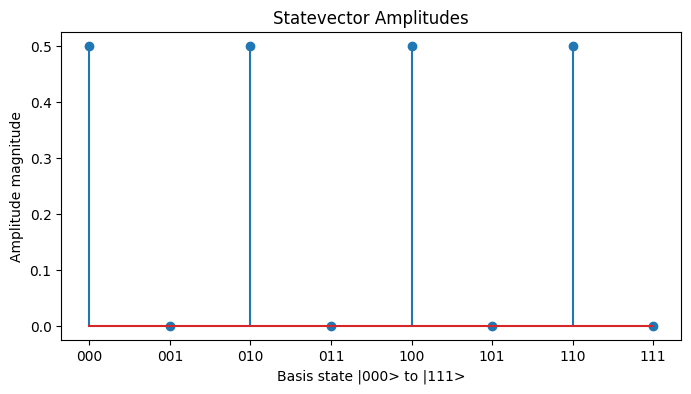

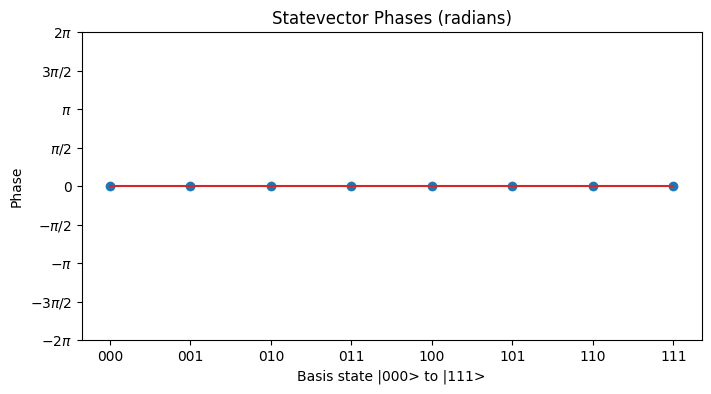

In [23]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


# 3-qubit superposition |0> + |2> + |4> + |6>
amplitudes = [1/2, 0, 1/2, 0, 1/2, 0, 1/2, 0]

# Create circuit
qc = QuantumCircuit(3)
qc.initialize(amplitudes, [0,1,2])


# Apply QFT
QFT(qc, 3)

# Apply IQFT
IQFT(qc,3)

# Get statevector
sv = Statevector.from_instruction(qc)

# Plot amplitudes (magnitudes)
plt.figure(figsize=(8,4))
plt.stem(range(8), np.abs(sv.data))
plt.title("Statevector Amplitudes")
plt.xlabel("Basis state |000> to |111>")
plt.ylabel("Amplitude magnitude")
plt.xticks(range(8), [format(i,'03b') for i in range(8)])
plt.show()

# Plot phases
plt.figure(figsize=(8,4))
plt.stem(range(8), np.angle(sv.data))
plt.title("Statevector Phases (radians)")
plt.xlabel("Basis state |000> to |111>")
plt.ylabel("Phase")
plt.xticks(range(8), [format(i,'03b') for i in range(8)])

yticks = [-2*np.pi, -3*np.pi/2, -np.pi, -np.pi/2, 0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
ytick_labels = [r'$-2\pi$', r'$-3\pi/2$', r'$-\pi$', r'$-\pi/2$', '0',
                r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
plt.yticks(yticks, ytick_labels)
plt.show()

As we can see all the phases have been reset to 0 and the amplitudes of our system are a equal super position of our initial state. This means the IQFT correctly reversed the action of the QFT.

## QFT Applications
The QFT has applications in many different quantum algorithms such as quantum machine learning, phase estimation, and most notably Shor's factoring algorithm.

Unfortunately despite the speedup the QFT offers over the DFT and the FFT, it is not a complete replacement for those other algorthims. When a quantum system is measured after the QFT is applied we only obtain one measurement result of one amplitude, not all the Fourier Coeffients like we do with FFT and DFT. Because of this the QFT is only really used as a subroutine inside other quantum algorithms, not as a seperate algorithm run by itself.

# Quantum Computing Questions

In [26]:
# @title Question 5
ask_mcq(
    "q5",
    "What does the Inverse Fourier Transform do?",
    ["Removes high frequencies", "Converts frequency-domain data back to the original time-domain signal", "Squares all amplitudes","Encrypts the signal"],
    correct="Converts frequency-domain data back to the original time-domain signal"
)



HTML(value="<b style='font-size:24px'>What does the Inverse Fourier Transform do?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Removes high frequencies', 'C…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [27]:
# @title Question 6
ask_mcq(
    "q6",
    "What are some practical applications of QFT?",
    ["Image compression ", "Sorting classical array", "Period finding and phase estimation in quantum algorithms", "Classical database indexing"],
    correct="Period finding and phase estimation in quantum algorithms"
)




HTML(value="<b style='font-size:24px'>What are some practical applications of QFT?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Image compression ', 'Sorting…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [28]:
# @title Question 7
ask_mcq(
    "q7",
    "What three gates does the QFT primarily utilize?",
    ["Pauli-X, Pauli-Y, Pauli-Z", "CNOT, Toffoli, SWAP", "Hadamard, controlled phase rotations, SWAP", "Measurement, Pauli-X, reset"],
    correct="Hadamard, controlled phase rotations, SWAP"
)




HTML(value="<b style='font-size:24px'>What three gates does the QFT primarily utilize?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Pauli-X, Pauli-Y, Pauli-Z', '…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [29]:
# @title Question 8
ask_mcq(
    "q8",
    "What does the QFT do?",
    ["Measures all qubits", "Performs classical convolution", "Maps computational basis states into phase-encoded superpositions (quantum frequency domain)", "Copies quantum states"],
    correct="Maps computational basis states into phase-encoded superpositions (quantum frequency domain)"
)





HTML(value="<b style='font-size:24px'>What does the QFT do?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('Measures all qubits', 'Perfor…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [30]:
# @title Question 9
ask_mcq(
    "q9",
    "Why is QFT not a complete replacement for DFT?",
    ["QFT is slower than FFT in all cases", "QFT requires analog hardware", "QFT outputs amplitudes that cannot all be measured simultaneously", "QFT cannot compute phases"],
    correct="QFT outputs amplitudes that cannot all be measured simultaneously"
)




HTML(value="<b style='font-size:24px'>Why is QFT not a complete replacement for DFT?</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('QFT is slower than FFT in all…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

In [31]:
# @title Question 10
ask_mcq(
    "q10",
    "Measuring a quantum state after QFT typically gives:",
    ["All Fourier coefficients", "Half the coefficients", "One sampled outcome", "No information"],
    correct="One sampled outcome"
)



HTML(value="<b style='font-size:24px'>Measuring a quantum state after QFT typically gives:</b>")

RadioButtons(_dom_classes=('big-radio',), layout=Layout(width='auto'), options=('All Fourier coefficients', 'H…

Button(button_style='primary', description='Check answer', style=ButtonStyle())

Output()

HTML(value='\n    <style>\n    .big-radio label {\n        font-size: 20px !important;\n    }\n    </style>\n …

#OLD The Classial Fourier Transform

### The Fourier Transform
The classical Fourier Transform is used to convert a signal in the time domain into a signal in the frequency domain. It is one of the most important discoveries of modern engineering and has applications in anything related to sound, electronic signals, data compression, and medical imaging. Because of how broad and utilized the Fourier Transform is there are a few different 'versions' of it for different applications. In this notebook we will focus on the Discete Fourier Transform (DFT) and use it as a stepping stone into the Quantum Fourier Transform (QFT).

We will go over the DFT fisrt as it is the most intuitive and can help get a feel for what is going on but then move on to the FFT which the actual algorithm computer scientists use to compute the transform.

The DFT is heavily based in mathmatical formulas which can be daunting and hard to understand but are neccisary to get the full picture of what the DFT does. For this notebook we will provide the equations and explain how they work but put more of a focus on how the DFT works conceptually (ie what its input is, what the transform does, and what the output is).

Say you are given a periodic signal, we can think of it as just a sum of a bunch of sin waves, the goal of the DFT is to pick apart the signal and find the frequencies of each of those waves. Then you can perform whatever calculations or analysis on those frequencies that you would like. Then you can perform something called the Inverse Fourier Transform which will turn those frequencies back into a signal in the time domain.




Now we will look at the mathmatical formula for the DFT
The DFT is commonly defined as:

$X_k = \sum_{n=0}^{N-1} x_n e^{-2\pi i kn/N}$

Where $x_n$ is the orignal input signal, $n$ which signal is currently being looked at, $N$ the total number of signals the input is being decomposed to (larger $N$ means more frequencies and less seperation between them), $k$ the value of the frequency (the larger $k$ is the higher the frequency of the wave), and $X_k$ which we call the Fourier Coeffient of that frequency (holds the amplitdue and phase associated with the frequency).

The Inverse Fourier Transform is very similar to the DFT, it is defined as:


$x_n = \frac{1}{N} \sum_{k=0}^{N-1} X_k e^{2\pi i kn/N}$

where $X_k$ are the frequency-domain coefficients and  are the time-domain signal values.

All that has changed is the places of $X_k$ and $x_n$ have swapped and the sign of $e^{-2\pi i kn/N}$ has swapped.

Applying the DFT followed by the IDFT recovers the original signal. This makes the DFT/IDFT pair useful for signal processing workflows: transform to frequency domain, apply filters or analysis, then transform back to get the modified signal.

Now we will get into the formal mathmatical definition. To make the formulas more compact we will define $\omega_N$ as

$\omega_N = e^{2\pi i/N} = \cos\left(\frac{2\pi}{N}\right) + i\sin\left(\frac{2\pi}{N}\right)$

The DFt can be expressed as a matrix-vector operation:

$$\mathbf{X} = \mathbf{F} \mathbf{x}$$

where $\mathbf{F}$ is the DFT matrix and $\mathbf{x}$ is the input signal vector.

DFT Matrix

$$\mathbf{F} = \frac{1}{\sqrt{N}} \begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
1 & \omega_N & \omega_N^2 & \cdots & \omega_N^{N-1} \\
1 & \omega_N^2 & \omega_N^4 & \cdots & \omega_N^{2(N-1)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & \omega_N^{N-1} & \omega_N^{2(N-1)} & \cdots & \omega_N^{(N-1)^2}
\end{pmatrix}$$

Input and Output Vectors

$$\mathbf{x} = \begin{pmatrix} x_0 \\ x_1 \\ x_2 \\ \vdots \\ x_{N-1} \end{pmatrix}, \quad \mathbf{X} = \begin{pmatrix} X_0 \\ X_1 \\ X_2 \\ \vdots \\ X_{N-1} \end{pmatrix}$$

Element-wise Formula

$$X_k = \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} x_n \omega_N^{-nk}$$

where $\omega_N = e^{2\pi i/N}$ and $k \in \{0, 1, \ldots, N-1\}$.

### Fast Fourier Transform (FFT)
When computers actually calculate the DFT they use a special idea called the Fast Fourier Transform (FFT). The FFT makes use of some special mathmatical ideas.

Firstly, it uses the idea that functions can be split up into even and odd parts. Specifically it splits up the even and odd $x_n$ terms into ($x_0, x_2, x_4 ...$) and ($x_1, x_3, x_5 ... $). This also means you can rewrite the odd terms to be the "twiddle factor" times the even terms.

The twiddle factor is definded to be $\omega_N = e^{-2\pi i/N}$ and it can be though of as a rotation in the complex plane.

We can write the FFT in summation notation as the following

$X_k = \sum_{m=0}^{N/2-1} x_{2m} e^{-2\pi i k(2m)/N} + e^{-2\pi i k/N} \sum_{m=0}^{N/2-1} x_{2m+1} e^{-2\pi i k(2m)/N}$




$\omega_N^{k+N/2} = -\omega_N^k$. <- rewrite this to make more sense

This means the DFT outputs repeat with a sign flip at the halfway point. Therefore, we only need to compute half the frequencies and can derive the rest for free by using a '-' sign instead of a '+' sign.

By combining these two ideas—dividing the problem recursively and exploiting the periodicity—we can build up the full DFT from many small pieces using divide and conquer recursion as shown below.

### **Fast Fourier Transform (FFT)**

When computers calculate the DFT, they don't use the formula directly that would be too slow. Instead, they use a smarter algorithm called the **Fast Fourier Transform (FFT)**, which gets the exact same answer but much faster.

**The core idea: split the problem in half.**

Instead of computing the DFT of all $N$ samples at once, we split the input into two smaller groups:

- **Even-indexed samples:** $x_0, x_2, x_4, \ldots$
- **Odd-indexed samples:** $x_1, x_3, x_5, \ldots$

We compute the DFT of each group separately (each is half the size), then combine the results. This is much cheaper than doing everything at once.

**Why splitting works — the math.**

When you separate even and odd samples, the DFT formula naturally breaks into two halves:

$$X_k = \underbrace{\sum_{m=0}^{N/2-1} x_{2m}\, e^{-2\pi i k(2m)/N}}_{\text{DFT of even samples}} + \underbrace{e^{-2\pi i k/N}}_{\text{twiddle factor}} \cdot \underbrace{\sum_{m=0}^{N/2-1} x_{2m+1}\, e^{-2\pi i k(2m)/N}}_{\text{DFT of odd samples}}$$

We call the term $W_k = e^{-2\pi ik/N}$ the **twiddle factor**. Think of it as a rotation: it adjusts the phase of the odd half before we add it to the even half.

**Getting the second half of outputs for free.**

Here's the clever part. The twiddle factor has a special symmetry property:

$$W_{k+N/2} = -W_k$$

In other words, if you shift the frequency index by $N/2$, the twiddle factor just flips its sign. This means once you've computed the first half of the outputs, you already have everything you need for the second half just change the $"+"$ to a $"-"$:

$$X_k = E_k + W_k \cdot O_k$$
$$X_{k + N/2} = E_k - W_k \cdot O_k$$

where $E_k$ is the DFT of the even samples and $O_k$ is the DFT of the odd samples. **Two outputs, one computation.**

**Then repeat recursively.**

Each half-size DFT can itself be split into even and odd parts, and so on, until you're down to single samples (which are trivially their own DFT). This divide-and-conquer recursion is what drops the cost from $O(N^2)$ all the way down to $O(N \log N)$.

The Butterfly Operation (Divide and Conquer)

After computing smaller DFTs, we recombine using:

$$X_k = E_k + W_k O_k$$

$$X_{k+N/2} = E_k - W_k O_k$$

where:
- $E_k$ = even part
- $O_k$ = odd part  
- $W_k = e^{-2\pi i k/N}$ (twiddle factor)

FFT Algorithm Pseudocode


$$\begin{align}
&\quad N \gets \text{length}(x) \\
&\quad \text{if } N = 1 \text{ then} \\
&\quad \quad \text{return } x \\
&\quad \text{even} \gets \text{FFT}(x[0, 2, 4, \ldots]) \\
&\quad \text{odd} \gets \text{FFT}(x[1, 3, 5, \ldots]) \\
&\quad X \gets [0, 0, \ldots, 0] \quad \text{(length } N\text{)} \\
&\quad \text{for } k = 0 \text{ to } N/2 - 1 \text{ do} \\
&\quad \quad W_k \gets e^{-2\pi i k/N} \\
&\quad \quad X[k] \gets \text{even}[k] + W_k \cdot \text{odd}[k] \\
&\quad \quad X[k + N/2] \gets \text{even}[k] - W_k \cdot \text{odd}[k] \\
&\quad \text{end for} \\
&\quad \text{return } X
\end{align}$$

Key Steps

1. **Base case**: If input length is 1, return it immediately
2. **Divide**: Split input into even and odd indexed elements
3. **Conquer**: Recursively compute FFT of each half
4. **Combine**: Use butterfly operations to recombine results

Each time it calls "FFT" it is essentially computing the DFT on a smaller part of the signal, then combining them all back up together. The use of the FFT changes the runtime from $O(N^2)$ to $O(N \log N)$. An interactive visualisation of how the FFT transforms a signal into its frequencies is shown below.

In [ ]:
# @title Default title text
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# -------------------------
# Parsing: "1 0 2:45" means:
# freq 0 has amp=1
# freq 1 has amp=0
# freq 2 has amp=2, phase=45 degrees
#
# Optional explicit frequency:
# "2@5:30" means freq=5 amp=2 phase=30
# "1@-3" means freq=-3 amp=1 phase=0
# -------------------------
def parse_cycles(text: str):
    toks = [t for t in text.replace(",", " ").split() if t.strip()]
    cycles = []
    for i, tok in enumerate(toks):
        freq = i
        if "@" in tok:
            tok, f = tok.split("@", 1)
            freq = int(f)

        if ":" in tok:
            a, ph = tok.split(":", 1)
            amp = float(a)
            phase_deg = float(ph)
        else:
            amp = float(tok)
            phase_deg = 0.0

        if np.isnan(amp):
            continue
        cycles.append({"freq": freq, "amp": amp, "phase": np.deg2rad(phase_deg)})
    return cycles

def dft_from_time_samples(samples):
    x = np.array(samples, dtype=float)
    N = len(x)
    X = np.fft.fft(x) / N
    cycles = []
    for k in range(N):
        amp = np.abs(X[k])
        phase = np.angle(X[k])
        cycles.append({"freq": k, "amp": amp, "phase": phase})
    return cycles

def cycles_to_string(cycles, max_terms=16, amp_digits=2, phase_digits=0):
    out = []
    for c in cycles[:max_terms]:
        amp = round(c["amp"], amp_digits)
        ph = round(np.rad2deg(c["phase"]), phase_digits)
        if amp == 0:
            out.append("0")
        elif ph == 0:
            out.append(f"{amp}")
        else:
            out.append(f"{amp}:{ph}")
    return " ".join(out)

def phasor_sum(cycles, t):
    # total complex value at time t (radians)
    z = 0j
    parts = []
    for c in cycles:
        contrib = c["amp"] * np.exp(1j * (c["freq"] * t + c["phase"]))
        parts.append(contrib)
        z += contrib
    return z, parts

def basis_phasor(freq_k, t):
    # e^{-i k t} (FFT "spin backwards")
    return np.exp(-1j * freq_k * t)

# -------------------------
# Main renderer
# -------------------------
def render(
    input_mode,
    cycles_text,
    time_text,
    running,
    t_slider,
    show_total,
    show_parts,
    show_ticks,
    derive_mode,
    derive_k,
    N_ticks
):
    # Build cycles depending on mode
    if input_mode == "Cycles → Wave":
        cycles = parse_cycles(cycles_text)
        samples = None
    else:
        toks = [t for t in time_text.replace(",", " ").split() if t.strip()]
        samples = [float(t) for t in toks]
        if len(samples) < 2:
            cycles = [{"freq": 0, "amp": 0, "phase": 0}]
        else:
            cycles = dft_from_time_samples(samples)

    # Time setup
    steps = 180
    t = (t_slider / steps) * 2*np.pi

    # Discrete tick points
    N = int(N_ticks)
    ts = np.linspace(0, 2*np.pi, N, endpoint=False)

    # Continuous curve for wave
    fine = np.linspace(0, 2*np.pi, 720)
    y_total = np.array([phasor_sum(cycles, tt)[0].real for tt in fine])

    # Current phasors
    z, parts = phasor_sum(cycles, t)

    # ---- Plot ----
    plt.close("all")
    fig, (axC, axT) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios":[1, 2]})

    # --- Left: unit-circle style / phasors ---
    axC.set_aspect("equal", adjustable="box")
    axC.axhline(0, lw=1, alpha=0.35)
    axC.axvline(0, lw=1, alpha=0.35)

    # FIX: choose a scale so the dot (tip of the sum) ALWAYS stays in frame.
    # The max possible distance of the tip is <= sum(|amp_i|)
    chain_radius = sum(abs(c["amp"]) for c in cycles)
    radius = max(1.0, chain_radius) * 1.15  # add padding so it doesn't touch the border

    circle = plt.Circle((0,0), 1.0, fill=False, lw=1, alpha=0.35)
    axC.add_patch(circle)

    # Draw vectors tip-to-tail (epicycles)
    origin = 0+0j
    if show_parts:
        for contrib in parts:
            axC.plot([origin.real, (origin+contrib).real], [origin.imag, (origin+contrib).imag], lw=2, alpha=0.75)
            origin += contrib

    if show_total:
        axC.plot([0, z.real], [0, z.imag], lw=3, alpha=0.9)
        axC.scatter([z.real], [z.imag], s=45)

    axC.set_xlim(-radius, radius)
    axC.set_ylim(-radius, radius)
    axC.set_title("Rotating vectors (phasors)")
    axC.set_xticks([])
    axC.set_yticks([])

    # --- Right: time wave ---
    axT.axhline(0, lw=1, alpha=0.35)
    axT.plot(fine, y_total, lw=2, label="Total wave")

    # Show parts (each frequency's real contribution)
    if show_parts:
        for c in cycles[:12]:  # keep it readable
            part = np.array([(c["amp"] * np.exp(1j*(c["freq"]*tt + c["phase"]))).real for tt in fine])
            axT.plot(fine, part, lw=1, alpha=0.35)

    # Ticks (discrete samples)
    if show_ticks:
        ys = np.array([phasor_sum(cycles, tt)[0].real for tt in ts])
        axT.scatter(ts, ys, s=25, alpha=0.9)
        for tt in ts:
            axT.axvline(tt, lw=0.6, alpha=0.12)

    # Current time marker
    axT.axvline(t, lw=2, alpha=0.6)
    axT.scatter([t], [z.real], s=60)

    axT.set_xlim(0, 2*np.pi)
    axT.set_title("Wave over time (real part)")
    axT.set_xlabel("time (radians, 0 → 2π)")

    # --- Derive mode: show “spinning backwards” idea for one frequency ---
    if derive_mode:
        k = int(derive_k)
        # sample-based estimate (like DFT)
        ys = np.array([phasor_sum(cycles, tt)[0].real for tt in ts])
        basis = np.array([np.cos(k*tt) for tt in ts])  # beginner-friendly: cosine basis
        prod = ys * basis
        est = prod.mean()

        axT2 = axT.twinx()
        axT2.plot(ts, basis, marker="o", lw=1.2, alpha=0.5)
        axT2.plot(ts, prod, marker="o", lw=1.2, alpha=0.5)
        axT2.set_ylabel(f"Derive k={k}: basis & product (avg≈{est:.3f})")

    # Helpful caption (0.02
    if input_mode == "Time samples → Cycles (DFT)":
        axT.text(0.02, 0.95, "You entered time samples → we computed cycles (DFT).",
                 transform=axT.transAxes, va="top", alpha=0.75)

    plt.tight_layout()
    plt.show()

# -------------------------
# Widgets (UI)
# -------------------------

input_mode = widgets.ToggleButtons(
    options=["Cycles → Wave", "Time samples → Cycles (DFT)"],
    value="Cycles → Wave",
    description="Mode:",
    style={
        "button_width": "initial",        # let buttons size to their text
        "description_width": "initial"    # doesn't squeeze the label
    },
    layout=widgets.Layout(width="700px")  # give the whole control enough room
)

cycles_text = widgets.Text(
    value="1 0 2:45",
    description="Cycles:",
    layout=widgets.Layout(width="420px")
)

time_text = widgets.Text(
    value="1 2 3 2 1 0 -1 0",
    description="Time:",
    layout=widgets.Layout(width="420px")
)

running = widgets.Checkbox(value=True, description="Running")
show_total = widgets.Checkbox(value=True, description="Total")
show_parts = widgets.Checkbox(value=True, description="Parts")
show_ticks = widgets.Checkbox(value=False, description="Ticks")
derive_mode = widgets.Checkbox(value=False, description="Derive")
derive_k = widgets.IntSlider(value=1, min=0, max=20, step=1, description="k")
N_ticks = widgets.IntSlider(value=16, min=4, max=64, step=1, description="Ticks N")

steps = 180
t_slider = widgets.IntSlider(value=0, min=0, max=steps, step=1, description="Time")

play = widgets.Play(interval=50, value=0, min=0, max=steps, step=1)
widgets.jslink((play, "value"), (t_slider, "value"))

out = widgets.Output()

def refresh(*_):
    with out:
        clear_output(wait=True)
        render(
            input_mode.value,
            cycles_text.value,
            time_text.value,
            running.value,
            t_slider.value,
            show_total.value,
            show_parts.value,
            show_ticks.value,
            derive_mode.value,
            derive_k.value,
            N_ticks.value
        )

# auto-advance if running
def tick(change):
    if running.value:
        play._playing = True
    else:
        play._playing = False

running.observe(tick, names="value")

for w in [input_mode, cycles_text, time_text, t_slider, show_total, show_parts, show_ticks, derive_mode, derive_k, N_ticks]:
    w.observe(refresh, names="value")

controls1 = widgets.HBox([input_mode])
controls2 = widgets.HBox([cycles_text, time_text])
controls3 = widgets.HBox([show_total, show_parts, show_ticks, derive_mode, derive_k, N_ticks])
controls4 = widgets.HBox([running, play, t_slider])

display(widgets.VBox([controls1, controls2, controls3, controls4, out]))
refresh()

In [ ]:
import sys
!{sys.executable} -m pip install -U numpy matplotlib ipympl ipywidgets

from google.colab import output
output.enable_custom_widget_manager()

%matplotlib widget
import matplotlib.pyplot as plt

In [ ]:
import matplotlib, sys
print("python:", sys.executable)
print("matplotlib:", matplotlib.__version__)
import ipympl
print("ipympl:", ipympl.__version__)

In [ ]:
import matplotlib
print(matplotlib.get_backend())

In [ ]:
# @title Interactive FFT demo with a slider to change frequency (Hz) live

""" Use Zoom/Pan tool to zoom into FFT plot for better ty """

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider


def compute_fft_mag(x, fs):
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    mag = np.abs(X) / len(x)
    return freqs, mag


def make_sine(t, hz, amp):
    return amp * np.sin(2 * np.pi * hz * t)


def main():
    # Sampling setup
    fs = 1000          # samples/sec
    duration = 1.0     # seconds
    t = np.arange(0, duration, 1.0 / fs)

    # Initial params
    hz0 = 50.0
    amp0 = 1.0

    x = make_sine(t, hz0, amp0)
    freqs, mag = compute_fft_mag(x, fs)

    # Bigger figure + better spacing
    fig, (ax_time, ax_fft) = plt.subplots(2, 1, figsize=(12, 7))

    # Reserve enough bottom for 2 sliders, plus extra top room for suptitle
    fig.subplots_adjust(left=0.10, right=0.98, top=0.88, bottom=0.22, hspace=0.45)

    # Time-domain line
    (line_time,) = ax_time.plot(t, x, lw=1)
    ax_time.set_title("Time Domain Signal", pad=8)
    ax_time.set_xlabel("Time (s)", labelpad=6)
    ax_time.set_ylabel("Amplitude")
    ax_time.grid(True, alpha=0.25)

    # Frequency-domain line
    (line_fft,) = ax_fft.plot(freqs, mag, lw=1)
    ax_fft.set_title("FFT Magnitude Spectrum", pad=8)
    ax_fft.set_xlabel("Frequency (Hz)", labelpad=6)
    ax_fft.set_ylabel("Magnitude")

    ax_fft.set_xlim(0, 350) # limit x-axis to 250 Hz for better visibility
    ax_fft.grid(True, alpha=0.25)

    # Slider axes (moved slightly lower + thinner so they fit cleanly)
    left = 0.12
    width = 0.78
    ax_hz = fig.add_axes([left, 0.11, width, 0.03])
    ax_amp = fig.add_axes([left, 0.06, width, 0.03])

    # Sliders
    # change valmax and valstep for finer control
    hz_slider = Slider(ax=ax_hz, label="Frequency (Hz)", valmin=1, valmax=350, valinit=hz0, valstep=1)
    amp_slider = Slider(ax=ax_amp, label="Amplitude", valmin=0.1, valmax=2.0, valinit=amp0, valstep=0.1)

    # Update function called whenever slider moves
    def update(_):
        hz = hz_slider.val
        amp = amp_slider.val

        x_new = make_sine(t, hz, amp)
        freqs_new, mag_new = compute_fft_mag(x_new, fs)

        line_time.set_ydata(x_new)
        line_fft.set_ydata(mag_new)

        # Keep y-limits reasonable as amplitude changes
        ax_time.set_ylim(-2.2, 2.2)
        ax_fft.set_ylim(0, max(0.001, float(mag_new.max()) * 1.15))

        fig.canvas.draw_idle()

    hz_slider.on_changed(update)
    amp_slider.on_changed(update)

    fig.suptitle(
        "Interactive FFT: Move the slider to change Hz and watch the spectrum shift",
        fontsize=14,
        y=0.97,  # lift the suptitle a bit
    )

    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

def compute_fft_mag(x, fs, *, pad_factor=8, window="hann"):

    x = np.asarray(x)

    if window == "hann":
        w = np.hanning(len(x))
        xw = x * w
        # Coherent gain correction so magnitudes stay intuitive-ish
        cg = w.mean()
        xw = xw / max(cg, 1e-12)
    else:
        xw = x

    n = len(xw)
    nfft = int(pad_factor * n)

    X = np.fft.rfft(xw, n=nfft)
    freqs = np.fft.rfftfreq(nfft, d=1.0 / fs)

    # magnitude scaling (roughly "per-sample" amplitude-like)
    mag = np.abs(X) / n
    return freqs, mag

def make_two_sines(t, f1, a1, f2, a2):
    return a1 * np.sin(2 * np.pi * f1 * t) + a2 * np.sin(2 * np.pi * f2 * t)

# ---- Sampling setup ----
fs = 2000          # samples/sec (higher lets you explore higher frequencies)
duration = 1.0     # seconds (increase for true finer FFT resolution)
t = np.arange(0, duration, 1.0 / fs)

# ---- Initial params ----
f1_0, a1_0 = 50.0, 1.0
f2_0, a2_0 = 120.0, 0.6  # second tone adds another peak

x = make_two_sines(t, f1_0, a1_0, f2_0, a2_0)
freqs, mag = compute_fft_mag(x, fs, pad_factor=8, window="hann")

# ---- Figure ----
fig, (ax_time, ax_fft) = plt.subplots(2, 1, figsize=(12, 7))
fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.28, hspace=0.45)

(line_time,) = ax_time.plot(t, x, lw=1)
ax_time.set_title("Time Domain Signal (Two Tones)")
ax_time.set_xlabel("Time (s)")
ax_time.set_ylabel("Amplitude")
ax_time.grid(True, alpha=0.25)

(line_fft,) = ax_fft.plot(freqs, mag, lw=1)
ax_fft.set_title("FFT Magnitude Spectrum")
ax_fft.set_xlabel("Frequency (Hz)")
ax_fft.set_ylabel("Magnitude")
ax_fft.grid(True, alpha=0.25)

# Show up to Nyquist
nyquist = fs / 2
ax_fft.set_xlim(0, min(600, nyquist))

# ---- Sliders ----
left = 0.12
width = 0.78

ax_f1  = fig.add_axes([left, 0.18, width, 0.03])
ax_a1  = fig.add_axes([left, 0.13, width, 0.03])
ax_f2  = fig.add_axes([left, 0.08, width, 0.03])
ax_a2  = fig.add_axes([left, 0.03, width, 0.03])

fmax = max(2, int(nyquist - 1))

f1_slider = Slider(ax=ax_f1, label="Tone 1 Frequency (Hz)", valmin=1, valmax=fmax, valinit=f1_0, valstep=0.5)
a1_slider = Slider(ax=ax_a1, label="Tone 1 Amplitude",      valmin=0.0, valmax=2.0, valinit=a1_0, valstep=0.05)

f2_slider = Slider(ax=ax_f2, label="Tone 2 Frequency (Hz)", valmin=1, valmax=fmax, valinit=f2_0, valstep=0.5)
a2_slider = Slider(ax=ax_a2, label="Tone 2 Amplitude",      valmin=0.0, valmax=2.0, valinit=a2_0, valstep=0.05)

def update(_):
    f1, a1 = f1_slider.val, a1_slider.val
    f2, a2 = f2_slider.val, a2_slider.val

    x_new = make_two_sines(t, f1, a1, f2, a2)
    freqs_new, mag_new = compute_fft_mag(x_new, fs, pad_factor=8, window="hann")

    line_time.set_ydata(x_new)
    line_fft.set_xdata(freqs_new)
    line_fft.set_ydata(mag_new)

    # keep axes reasonable
    ax_time.set_ylim(-2.5, 2.5)
    ax_fft.set_ylim(0, max(0.001, float(mag_new.max()) * 1.15))

    fig.canvas.draw_idle()

for s in (f1_slider, a1_slider, f2_slider, a2_slider):
    s.on_changed(update)

fig.suptitle("Interactive FFT (Two Tones)", fontsize=14)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

def compute_fft_mag(x, fs, *, pad_factor=8, window="hann"):
    x = np.asarray(x)

    if window == "hann":
        w = np.hanning(len(x))
        xw = x * w
        cg = w.mean()
        xw = xw / max(cg, 1e-12)
    else:
        xw = x

    n = len(xw)
    nfft = int(pad_factor * n)

    X = np.fft.rfft(xw, n=nfft)
    freqs = np.fft.rfftfreq(nfft, d=1.0 / fs)
    mag = np.abs(X) / n
    return freqs, mag

def make_three_sines(t, f1, a1, f2, a2, f3, a3):
    s1 = a1 * np.sin(2 * np.pi * f1 * t)
    s2 = a2 * np.sin(2 * np.pi * f2 * t)
    s3 = a3 * np.sin(2 * np.pi * f3 * t)
    return s1, s2, s3, (s1 + s2 + s3)

# ---- Sampling setup ----
fs = 2000
duration = 1.0
t = np.arange(0, duration, 1.0 / fs)

# ---- Initial params ----
f1_0, a1_0 = 50.0, 1.0
f2_0, a2_0 = 120.0, 0.6
f3_0, a3_0 = 220.0, 0.4

s1, s2, s3, x = make_three_sines(t, f1_0, a1_0, f2_0, a2_0, f3_0, a3_0)

freqs, mag1 = compute_fft_mag(s1, fs, pad_factor=8, window="hann")
_,     mag2 = compute_fft_mag(s2, fs, pad_factor=8, window="hann")
_,     mag3 = compute_fft_mag(s3, fs, pad_factor=8, window="hann")
_,     magS = compute_fft_mag(x,  fs, pad_factor=8, window="hann")

# ---- Figure ----
fig, (ax_time, ax_fft) = plt.subplots(2, 1, figsize=(12, 8))
# Need more bottom room for 6 sliders:
fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.42, hspace=0.45)

# Colors (explicit, per your request)
c1, c2, c3, csum = "tab:blue", "tab:orange", "tab:green", "k"

# Time domain lines (3 tones + sum)
(line_s1,)  = ax_time.plot(t, s1, lw=1.2, color=c1, label="Tone 1")
(line_s2,)  = ax_time.plot(t, s2, lw=1.2, color=c2, label="Tone 2")
(line_s3,)  = ax_time.plot(t, s3, lw=1.2, color=c3, label="Tone 3")
(line_sum,) = ax_time.plot(t, x,  lw=1.6, color=csum, alpha=0.75, label="Sum")

ax_time.set_title("Time Domain Signal (Three Tones)")
ax_time.set_xlabel("Time (s)")
ax_time.set_ylabel("Amplitude")
ax_time.grid(True, alpha=0.25)
ax_time.legend(loc="upper right")

# FFT lines (3 tones + sum)
(line_f1,)  = ax_fft.plot(freqs, mag1, lw=1.2, color=c1, label="FFT Tone 1")
(line_f2,)  = ax_fft.plot(freqs, mag2, lw=1.2, color=c2, label="FFT Tone 2")
(line_f3,)  = ax_fft.plot(freqs, mag3, lw=1.2, color=c3, label="FFT Tone 3")
(line_fS,)  = ax_fft.plot(freqs, magS, lw=1.6, color=csum, alpha=0.75, label="FFT Sum")

ax_fft.set_title("FFT Magnitude Spectrum")
ax_fft.set_xlabel("Frequency (Hz)")
ax_fft.set_ylabel("Magnitude")
ax_fft.grid(True, alpha=0.25)

nyquist = fs / 2
ax_fft.set_xlim(0, min(600, nyquist))
ax_fft.legend(loc="upper right")

# ---- Sliders ----
left = 0.12
width = 0.78
h = 0.03

# y positions (top to bottom)
y_f1, y_a1 = 0.34, 0.29
y_f2, y_a2 = 0.24, 0.19
y_f3, y_a3 = 0.14, 0.09

ax_f1 = fig.add_axes([left, y_f1, width, h])
ax_a1 = fig.add_axes([left, y_a1, width, h])
ax_f2 = fig.add_axes([left, y_f2, width, h])
ax_a2 = fig.add_axes([left, y_a2, width, h])
ax_f3 = fig.add_axes([left, y_f3, width, h])
ax_a3 = fig.add_axes([left, y_a3, width, h])

fmax = max(2, int(nyquist - 1))

f1_slider = Slider(ax=ax_f1, label="Tone 1 F (Hz)", valmin=1, valmax=fmax, valinit=f1_0, valstep=0.5)
a1_slider = Slider(ax=ax_a1, label="Tone 1 A",      valmin=0.0, valmax=2.0, valinit=a1_0, valstep=0.05)

f2_slider = Slider(ax=ax_f2, label="Tone 2 F (Hz)", valmin=1, valmax=fmax, valinit=f2_0, valstep=0.5)
a2_slider = Slider(ax=ax_a2, label="Tone 2 A",      valmin=0.0, valmax=2.0, valinit=a2_0, valstep=0.05)

f3_slider = Slider(ax=ax_f3, label="Tone 3 F (Hz)", valmin=1, valmax=fmax, valinit=f3_0, valstep=0.5)
a3_slider = Slider(ax=ax_a3, label="Tone 3 A",      valmin=0.0, valmax=2.0, valinit=a3_0, valstep=0.05)

def update(_):
    f1, a1 = f1_slider.val, a1_slider.val
    f2, a2 = f2_slider.val, a2_slider.val
    f3, a3 = f3_slider.val, a3_slider.val

    s1n, s2n, s3n, xn = make_three_sines(t, f1, a1, f2, a2, f3, a3)

    freqs_new, mag1n = compute_fft_mag(s1n, fs, pad_factor=8, window="hann")
    _,         mag2n = compute_fft_mag(s2n, fs, pad_factor=8, window="hann")
    _,         mag3n = compute_fft_mag(s3n, fs, pad_factor=8, window="hann")
    _,         magSn = compute_fft_mag(xn,  fs, pad_factor=8, window="hann")

    # update time lines
    line_s1.set_ydata(s1n)
    line_s2.set_ydata(s2n)
    line_s3.set_ydata(s3n)
    line_sum.set_ydata(xn)

    # update fft lines
    line_f1.set_xdata(freqs_new); line_f1.set_ydata(mag1n)
    line_f2.set_xdata(freqs_new); line_f2.set_ydata(mag2n)
    line_f3.set_xdata(freqs_new); line_f3.set_ydata(mag3n)
    line_fS.set_xdata(freqs_new); line_fS.set_ydata(magSn)

    # keep axes reasonable
    ax_time.set_ylim(-2.5, 2.5)
    ax_fft.set_ylim(0, max(0.001, float(magSn.max()) * 1.15))

    fig.canvas.draw_idle()

for s in (f1_slider, a1_slider, f2_slider, a2_slider, f3_slider, a3_slider):
    s.on_changed(update)

fig.suptitle("Interactive FFT", fontsize=14)
plt.show()

Another way we can think of what the DFT (or FFT) is doing is its mapping something from the time domain into the frequency domain. This idea of mapping something from one domain, and changing it into another domain is the same thing that the QFT does. In fact, the QFT and DFT are so similar mathmatically that the matrix representation for them both are the same execpt that the QFT transforms basis state vectors not signals.

The Quantum Fourier Transform (QFT) is the quantum version of the classical Discrete Fourier Transform (DFT). It takes a quantum state expressed in the computational basis and transforms it into a new basis that reveals frequency-like information through quantum phases.

Instead of operating on numbers, the QFT operates on probability amplitudes of a quantum state. It uses quantum phenomena like superposition and interference to perform the transformation extremely efficiently.

For an n-qubit system, the QFT can be implemented using only Hadamard gates, controlled phase rotations, and swap gates. While the QFT is faster than DFT it only works on the amplitudes of the basis states which cannot be directly measured on a real quantum machine so it is not a full replacement of the DFT.

# OLD QFT (to be deleted later)

In [ ]:
for i in reversed(range(n)): #reverse for qiskits qubit ordering
      # H gate
      circuit.h(i)
      #CP gates
      for k in range(i + 1, n):
          theta = np.pi / (2 ** (k - i))
          circuit.cp(theta, i, k)  # i = control, k = target
      #SWAP gates
    for i in range(n // 2):
      circuit.swap(i, n - i - 1)


def qft_rotations(circuit, n):
    """Performs qft on the first n qubits in circuit (without swaps)"""
    if n == 0:
        return circuit
    n -= 1
    circuit.h(n)
    for qubit in range(n):
        circuit.cp(pi/2**(n-qubit), qubit, n)
    # At the end of our function, we call the same function again on
    # the next qubits (we reduced n by one earlier in the function)
    qft_rotations(circuit, n)

### QFT vs FFT comparison
FFT has the structure
$$X_k = E_k + W_k O_k$$

$$X_{k+N/2} = E_k - W_k O_k$$

If you think about it, we can represent the right side of the equations as having the following strucutre:
\begin{matrix}
1 & 1 \\
1 & -1
\end{matrix}
where the first column represents $ E_k$ and the second column represents $O_k$ multiplied by the twiddle factor $W_k$.

This matrix structure is very similar to the $H$ gate, in fact the only difference is the $H$ gate has the normalizing factor of $\frac{1}{\sqrt2}$.

In FFT the the twiddle factor $W_k$ is calculated as $e^{2\pi i / 2^{m}}$. This is the same calculation as the quantum $CP$ gate. This is why the matrix representations of the FFT and QFT are so similar, they are essentally mirroring eachother.


### Quantum Fourier Transform Applications
While the QFT on its own isn't really that helpful, it does play a very important role in other quantum algorithms, most notiably Shor's factoring algorithm where instead of classical algorithms having $O(2^{n/2})$ order runtime Shor's has $O(n^3)$. While this moduel is on the QFT and not Shor's algorithm the QFT plays a key role in the expoental speed up that Shor's algorithm provides. Other common applications of the QFT include phase estimation and order finding.

### Gate-Level Implementation

The QFT can be efficiently implemented using only three types of quantum gates:

1. **Hadamard Gates**

For each qubit $j$, apply a Hadamard gate:

$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

This creates a superposition of the computational basis states.

2. **Controlled Phase Rotations**

After the Hadamard on qubit $j$, apply controlled phase gates $\text{CP}(\theta)$ from qubits $k > j$ to qubit $j$:

$$\text{CP}(\theta) = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & e^{i\theta} \end{pmatrix}$$

The angle is: $\theta = \frac{2\pi}{2^{k-j}}$

These phase gates create the interference patterns needed to encode the frequency information into the phases of the quantum state.

3. **SWAP Gates**

At the end, apply SWAP gates to reverse the order of the qubits:

$$\text{SWAP} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$$


This gate sequence transforms the quantum state from the computational basis to the frequency basis, with the QFT matrix encoded in the controlled phases and interference patterns.

In [ ]:
# @title Initial Imports
!pip install -q qiskit
!pip install -q qiskit-aer
!pip install -q pylatexenc


import qiskit
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
import numpy as np
%matplotlib inline

First we will create the inital state of the system in the computational basis.

In [ ]:
qubits = "101"
n = len(qubits)
qubits = qubits[::-1]
cir = qiskit.QuantumCircuit(n) #when circuit is created all qubits are in the |0> state


for i in range(n): #flip qubits that are 1 in the input string to prepare the desired state
    if qubits[i] == "1":
        cir.x(i)


### Circuit Level Algorithm Defintion
The algorithm works by applying a set of gates to each qubit. The following is the step-by-step outline:

1. For each qubit $i$ (from 0 to $n-1$):
   - Apply a Hadamard gate $H$ to qubit $i$
   - For each qubit $k$ where $k > i$ (higher-indexed qubits):
     - Apply a controlled phase gate $\text{CP}(\theta)$ from qubit $k$ (control) to qubit $i$ (target)
     - The phase angle is: $\theta = \frac{2\pi}{2^{k-i}}$

2. After processing all qubits, apply SWAP gates to reverse the qubit order:
   - Swap qubit $i$ with qubit $n-1-i$ for $i = 0$ to $\lfloor n/2 \rfloor - 1$

This creates the quantum superposition with encoded frequency information through phase interference.

In [ ]:
def QFT(circuit, n):
    for i in reversed(range(n)): #reverse for qiskits qubit ordering
      # H gate
      circuit.h(i)
      #CP gates
      for k in range(i + 1, n):
          theta = np.pi / (2 ** (k - i))
          circuit.cp(theta, i, k)  # i = control, k = target
      #SWAP gates
    for i in range(n // 2):
      circuit.swap(i, n - i - 1)


Print the circuit to verify correctness

In [ ]:
QFT(cir, n)
cir.draw(output="mpl")


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


# 3-qubit superposition |0> + |2> + |4> + |6>
amplitudes = [1/2, 0, 1/2, 0, 1/2, 0, 1/2, 0]

# Create circuit
qc = QuantumCircuit(3)
qc.initialize(amplitudes, [0,1,2])


# Apply QFT
QFT(qc, 3)

qc.draw(output="mpl")

# Get statevector
sv = Statevector.from_instruction(qc)

# Plot amplitudes (magnitudes)
plt.figure(figsize=(8,4))
plt.stem(range(8), np.abs(sv.data))
plt.title("Statevector Amplitudes")
plt.xlabel("Basis state |000> to |111>")
plt.ylabel("Amplitude magnitude")
plt.xticks(range(8), [format(i,'03b') for i in range(8)])
plt.show()

# Plot phases
plt.figure(figsize=(8,4))
plt.stem(range(8), np.angle(sv.data))
plt.title("Statevector Phases (radians)")
plt.xlabel("Basis state |000> to |111>")
plt.ylabel("Phase")
plt.xticks(range(8), [format(i,'03b') for i in range(8)])

yticks = [-2*np.pi, -3*np.pi/2, -np.pi, -np.pi/2, 0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
ytick_labels = [r'$-2\pi$', r'$-3\pi/2$', r'$-\pi$', r'$-\pi/2$', '0',
                r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
plt.yticks(yticks, ytick_labels)
plt.show()

The phases come from applying the hadamard gates. ie a phase of $\pi$ is applied to make the amplitude of a state negative.

#### The Inverse Quantum Fourier Transform (IQFT)

The Inverse Quantum Fourier Transform (IQFT) reverses the operation of the QFT, transforming from the frequency domain back to the computational basis. It is the Hermitian adjoint (conjugate transpose) of the QFT.

*Definition*

$$\text{IQFT} = \text{QFT}^{\dagger}$$

The IQFT acts on an $n$-qubit quantum state as:

$$\text{IQFT} |{k}⟩ = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} e^{-2\pi i xk/N} |{x}⟩$$

**Key Property: Reversibility**

Just like with the Inverse Fourier Transform, if you apply the IQFT to a system after you have applied the QFT to it you get back the original state.

$$\text{IQFT}(\text{QFT}(|{\psi})⟩) = |{\psi}⟩$$

This makes the QFT/IQFT pair a useful tool for quantum algorithms - you can transform to the frequency domain, perform operations, and transform back.

### Implementation

The IQFT is implemented by:
1. Reversing the order of gates from the QFT
2. Using the **negative** of the phase angles in the controlled phase gates
3. The algorithm structure mirrors the QFT but with conjugated operations

Lets also define the inverse QFT
It should be the case that if we apply the QFT then the IQFT we get the orignal state back

In [ ]:
def IQFT(circuit, n):
    #YOUR TURN: implement the inverse QFT by reversing the steps of the QFT and negating the angles for the controlled phase gates
    ### TODO implement the inverse QFT
  pass


In [ ]:
# @title Test cases to verify IQFT implementation


# Test 1: QFT followed by IQFT should recover the original state
print("Test 1: QFT → IQFT Recovery")
print("=" * 50)

# Get the statevector after QFT+IQFT
test_circuit = qiskit.QuantumCircuit(n)
for i in range(n):
    if qubits[i] == "1":
        test_circuit.x(i)

# Apply QFT then IQFT
QFT(test_circuit, n)
IQFT(test_circuit, n)

# Get the result
test_circuit.save_statevector()
sim = AerSimulator(method="statevector")
result = sim.run(test_circuit).result()
final_state = result.get_statevector()

# Calculate probabilities
final_probs = np.abs(final_state) ** 2

# Original state index (from binary string)
original_index = int(qubits[::-1], 2)

print(f"Original qubit state: {qubits}")
print(f"Original state index: |{original_index}⟩")
print(f"Probability of recovering original state: {final_probs[original_index]:.6f}")
print(f"Max probability deviation from 1.0: {1.0 - final_probs[original_index]:.2e}")

# Test passes if probability is very close to 1
test1_pass = final_probs[original_index] > 0.999
print(f"✓ Test 1 PASSED" if test1_pass else "✗ Test 1 FAILED")

print("\n" + "=" * 50)
print("Test 2: All other states should have near-zero probability")
print("=" * 50)

# Check that other basis states have negligible probability
other_state_probs = [final_probs[i] for i in range(len(final_probs)) if i != original_index]
max_other_prob = max(other_state_probs) if other_state_probs else 0

print(f"Maximum probability of other basis states: {max_other_prob:.2e}")

test2_pass = max_other_prob < 0.01
print(f"✓ Test 2 PASSED" if test2_pass else "✗ Test 2 FAILED")

print("\n" + "=" * 50)
print("Test 3: Verify IQFT is Hermitian adjoint of QFT")
print("=" * 50)

# The QFT followed by IQFT should produce identity (within numerical precision)
test_circuit2 = qiskit.QuantumCircuit(n)
test_circuit2.x(1)  # Put system in |010⟩ state

QFT(test_circuit2, n)
IQFT(test_circuit2, n)

test_circuit2.save_statevector()
result2 = sim.run(test_circuit2).result()
final_state2 = result2.get_statevector()
probs2 = np.abs(final_state2) ** 2

print(f"Starting state: |010⟩ (index 2)")
print(f"Probability of recovering |010⟩: {probs2[2]:.6f}")

test3_pass = probs2[2] > 0.999
print(f"✓ Test 3 PASSED" if test3_pass else "✗ Test 3 FAILED")

print("\n" + "=" * 50)
print(f"Overall: {'ALL TESTS PASSED ✓' if (test1_pass and test2_pass and test3_pass) else 'SOME TESTS FAILED ✗'}")
print("=" * 50)




Create the circuit again this time to run QFT then IQFT to make sure we get the original state back.

In [ ]:
qubits = "100"
n = len(qubits)
qubits = qubits[::-1]
cir = qiskit.QuantumCircuit(n) #when circuit is created all qubits are in the |0> state


for i in range(n): #flip qubits that are 1 in the input string to prepare the desired state
    if qubits[i] == "1":
        cir.x(i)
QFT(cir, n)
IQFT(cir, n)
cir.draw(output="mpl")
# plot the current probabilites
cir.save_statevector()
sim = AerSimulator(method="statevector")
result = sim.run(cir).result()
state = result.get_statevector()
labels = [format(i, f'0{n}b') for i in range(2**n)]
probs = np.abs(state) ** 2

plt.bar(labels, probs)
plt.xlabel("Basis states")
plt.ylabel("Probability")
plt.title("Probability distribution after QFT and IQFT")
plt.show()
None

write out states of binary 0,2,4,6
qft of periodicty
mention complexity

The circuits look correct and we get the target state back with what appears to be 100% probability

In [ ]:
# @title Question 6
ask_mcq(
    "q6",
    "What are some practical applications of QFT?",
    ["Image compression ", "Sorting classical array", "Period finding and phase estimation in quantum algorithms", "Classical database indexing"],
    correct="Period finding and phase estimation in quantum algorithms"
)




In [ ]:
# @title Question 7
ask_mcq(
    "q7",
    "What three gates does the QFT primarily utilize?",
    ["Pauli-X, Pauli-Y, Pauli-Z", "CNOT, Toffoli, SWAP", "Hadamard, controlled phase rotations, SWAP", "Measurement, Pauli-X, reset"],
    correct="Hadamard, controlled phase rotations, SWAP"
)




In [ ]:
# @title Question 8
ask_mcq(
    "q8",
    "What does the QFT do?",
    ["Measures all qubits", "Performs classical convolution", "Maps computational basis states into phase-encoded superpositions (quantum frequency domain)", "Copies quantum states"],
    correct="Maps computational basis states into phase-encoded superpositions (quantum frequency domain)"
)





In [ ]:
# @title Question 9
ask_mcq(
    "q9",
    "Why is QFT not a complete replacement for DFT?",
    ["QFT is slower than FFT in all cases", "QFT requires analog hardware", "QFT outputs amplitudes that cannot all be measured simultaneously", "QFT cannot compute phases"],
    correct="QFT outputs amplitudes that cannot all be measured simultaneously"
)




In [ ]:
# @title Question 10
ask_mcq(
    "q10",
    "Measuring a quantum state after QFT typically gives:",
    ["All Fourier coefficients", "Half the coefficients", "One sampled outcome", "No information"],
    correct="One sampled outcome"
)

